# 02 — Modeling: Seoul Bike Demand

## ขั้น 1 — นิยามปัญหา

**หน่วยของข้อมูล:** 1 แถว = 1 ชั่วโมง ของ **ทั้งระบบ** Seoul Bike (ยอดรวมทุกสถานีในเมือง) ตั้งแต่ 1 ธ.ค. 2017 – 30 พ.ย. 2018

| หัวข้อ | รายละเอียด |
|---|---|
| ชนิดงาน | **Regression** (`config.TASK = "regression"`) |
| ทำนายอะไร | **จำนวนจักรยานที่ถูกเช่าในชั่วโมงนั้น** (`rented_bike_count`, หน่วย **คัน/ชั่วโมง**) — เป็น label ที่มากับ dataset ไม่ต้องสร้างเอง |
| ใช้ทำอะไร | ผู้ให้บริการวางแผนจำนวนจักรยานที่ต้องพร้อมใช้ และจัดคนงานกระจายจักรยานล่วงหน้าในชั่วโมงที่คาดว่าจะมีคนเช่ามาก |
| input | สภาพอากาศ (อุณหภูมิ, ความชื้น, ลม, ทัศนวิสัย, dew point, แสงแดด, ฝน, หิมะ) + ฝน 3 ชั่วโมงก่อนหน้าในวันเดียวกัน + เวลา (ชั่วโมง, วันในสัปดาห์, เดือน) + ฤดู + วันหยุด |
| เมตริกหลัก | **MAE** (Mean Absolute Error, คัน/ชม.) |
| เมตริกรอง | **RMSE** (คัน/ชม.), **MSE** (คัน²/ชม.²), **R²** |

**ทำไม MAE เป็นเมตริกหลัก**
- หน่วยเดียวกับ target ตีความตรงๆ ว่า "โดยเฉลี่ยทายคลาดไปกี่คันต่อชั่วโมง" — ผู้ให้บริการเอาไปใช้ตัดสินใจได้ทันที
- target เบ้ขวา (`01_eda` 4.4: mean 756.8 > median 582.5) · RMSE ยกกำลังสองค่าคลาดเคลื่อน ชั่วโมงพีคไม่กี่ชั่วโมงจึงครอบงำคะแนน ส่วน MAE ให้น้ำหนักทุกชั่วโมงเท่ากัน
- รายงาน **RMSE** คู่กันเพื่อดูว่ามีชั่วโมงที่ทายพลาดแรงไหม (RMSE สูงกว่า MAE มาก = มี error ก้อนใหญ่บางจุด) · **R²** ไม่มีหน่วย บอกว่าอธิบายความแปรปรวนของยอดเช่าได้กี่ % ใช้เทียบกับงานอื่น แต่ไม่บอกว่าคลาดกี่คัน จึงเป็นเมตริกรอง
- **MSE** (Mean Squared Error) = ค่าเฉลี่ยของ (ค่าทำนาย − ค่าจริง)² และ RMSE = √MSE → ทั้งสองจัดลำดับโมเดลเหมือนกันเสมอ แต่ MSE มีหน่วยเป็น **คัน²** ตีความเป็นจำนวนจักรยานไม่ได้ → รายงาน MSE ไว้ในทุกตารางผลตามเกณฑ์ของโจทย์ แต่อธิบายผลด้วย RMSE

**ทำไมเป็น regression**
- target ของ dataset (`Rented Bike Count`) เป็นจำนวนนับต่อเนื่อง → ทำนายตรงๆ ได้เลย ไม่ต้องแปลงหรือตั้งเกณฑ์เอง
- ค่าที่ทำนายได้ (กี่คัน) นำไปวางแผนจำนวนจักรยานได้โดยตรง
- ใช้โจทย์เดียวกับโครงงานวิชา DS (`bike-trash-apps`)

**ขอบเขตที่ประกาศ**
- โมเดลใช้กับ **ชั่วโมงที่ระบบเปิดและนอกช่วงพายุที่กำหนดจากประกาศ KMA** เท่านั้น (`Functioning Day = Yes` และ date ไม่อยู่ใน `config.STORM_DATES`) · ขอบเขต/หลักฐานอยู่ใน 5.2; กฎใช้กับ train/test เหมือนกันและไม่ใช้ residual กำหนดวัน
- input ทุกตัวเป็นข้อมูลที่ **รู้ล่วงหน้าได้** (พยากรณ์อากาศ + ปฏิทิน) → **ไม่ใช้** ยอดเช่าของชั่วโมงก่อนหน้า (lag) เพราะนั่นคือการใช้ target ทำนาย target
- โจทย์คือ "อากาศและเวลาแบบนี้ → จะมีคนเช่ากี่คัน" ไม่ใช่ time-series forecasting → จึง split ตามวันแบบสุ่ม (ขั้น 3) ไม่ใช่ตัดตามเวลา
- ทำนายระดับทั้งเมือง ไม่ใช่รายสถานี (ข้อมูลไม่มีรายสถานี)

> ⚠️ กฎหลักของ notebook นี้
> - preprocessing ทุกขั้นที่เรียนจากข้อมูล (imputer, scaler, encoder, selector, PCA) อยู่ใน `Pipeline` — CV จะ fit ใหม่ทุก fold
> - เลือกโมเดล/ไฮเปอร์พารามิเตอร์ด้วย `GroupKFold` บน train (group = วันที่) และส่ง `groups=` ทุกครั้ง
> - **ห้ามดู test จนเลือกโมเดลเสร็จ** → ประเมิน test ครั้งเดียวตอนท้าย

### Setup
**โค้ดทำอะไร:** import ไลบรารี + `config.py` และตั้ง `set_config(display="text")` ให้ sklearn แสดง Pipeline เป็นข้อความ (อ่านได้ทั้งใน notebook และใน git diff)

In [1]:
# Setup — import ไลบรารี + config (ค่าคงที่ชุดเดียวกับ 01_eda) และตั้งค่าการแสดงผล
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import set_config

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import config

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")
set_config(display="text")   # แสดง Pipeline เป็นข้อความ (อ่านได้ทั้งใน notebook และ GitHub)


def savefig(name):
    # บันทึกรูปลง figures/ เพื่อนำไปใช้ในรายงาน
    plt.savefig(config.FIGURES_DIR / name, dpi=120, bbox_inches="tight")


print("TASK =", config.TASK, "| RANDOM_STATE =", config.RANDOM_STATE)

TASK = regression | RANDOM_STATE = 42


---
## ขั้น 5 — Feature engineering

### 5.1 โหลดข้อมูลและแยก train/test ตามรายการวันที่ commit ไว้
**โค้ดทำอะไร:**
- โหลด `config.DATA_CSV` ด้วย encoding/รูปแบบวันที่/ชื่อคอลัมน์จาก `config` (ค่าเดียวกับที่ตรวจแล้วใน `01_eda` ขั้น 2)
- อ่าน `data/splits/train_dates.csv`, `test_dates.csv` (สร้างใน `01_eda` ขั้น 3) แล้วเลือกแถวตามวัน — **ไม่สุ่มใหม่** ในไฟล์นี้ ทุก notebook ใช้วัน test ชุดเดียวกัน
- `assert` ว่าไม่มีวันซ้ำสองฝั่งและทุกแถวถูกจัดเข้าฝั่งใดฝั่งหนึ่ง
- ดู missing value ของ train ด้วย `isnull().sum()` และ `info()` (ไม่ดู test)

In [2]:
# ขั้น 5.1 — โหลดข้อมูลแล้วแยก train/test ตาม "รายการวัน" ที่ 01_eda บันทึกไว้
# แนวคิด: ไม่สุ่มแบ่งใหม่ใน notebook นี้ → ทุกคนและทุกการรันใช้วัน test ชุดเดียวกันเสมอ
data = pd.read_csv(config.DATA_CSV, encoding=config.RAW_ENCODING).rename(columns=config.COLUMN_MAP)
data["date"] = pd.to_datetime(data["date"], format=config.DATE_FORMAT)

train_dates = pd.to_datetime(pd.read_csv(config.TRAIN_DATES)["date"])
test_dates = pd.to_datetime(pd.read_csv(config.TEST_DATES)["date"])
assert not set(train_dates) & set(test_dates)          # ไม่มีวันไหนอยู่ทั้งสองฝั่ง

train = data[data["date"].isin(train_dates)].sort_values(["date", "hour"]).reset_index(drop=True)
test = data[data["date"].isin(test_dates)].sort_values(["date", "hour"]).reset_index(drop=True)
assert len(train) + len(test) == len(data)             # ทุกแถวอยู่ฝั่งใดฝั่งหนึ่ง ไม่หาย ไม่ซ้ำ
print(f"train: {train.shape} ({train['date'].nunique()} วัน) | test: {test.shape} ({test['date'].nunique()} วัน)")

# missing value ของ train (ไม่ดู test): ความชื้นที่ว่าง (01_eda 2.3) → ขั้น 6 เติมด้วย median ใน Pipeline
print("missing value ใน train:", train.isnull().sum()[lambda s: s > 0].to_dict())
train.info()

train: (7008, 14) (292 วัน) | test: (1752, 14) (73 วัน)
missing value ใน train: {'humidity_pct': 9}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                7008 non-null   datetime64[ns]
 1   rented_bike_count   7008 non-null   int64         
 2   hour                7008 non-null   int64         
 3   temp_c              7008 non-null   float64       
 4   humidity_pct        6999 non-null   float64       
 5   wind_speed_ms       7008 non-null   float64       
 6   visibility_10m      7008 non-null   int64         
 7   dew_point_c         7008 non-null   float64       
 8   solar_radiation_mj  7008 non-null   float64       
 9   rainfall_mm         7008 non-null   float64       
 10  snowfall_cm         7008 non-null   float64       
 11  seasons             7008 non-null   object        
 12  holi

**ผลลัพธ์:** train 7,008 แถว (292 วัน), test 1,752 แถว (73 วัน) — ตรงกับที่ได้ใน `01_eda` ขั้น 3 ทุกตัวเลข
จากนี้ `test` จะถูกแปลงด้วยฟังก์ชันเดียวกับ train (เพื่อให้พร้อมใช้ในขั้น 13) แต่ **ไม่พิมพ์/ไม่วิเคราะห์ค่าใดๆ ของ test**
- `info()` ของ train: `humidity_pct` **6,999 non-null จาก 7,008 → missing value 9 ค่า** · คอลัมน์อื่นครบ → เติมในขั้น 6

### 5.2 กฎกำหนดขอบเขตและแก้ค่าเซนเซอร์ (ใช้กับ train/test เหมือนกัน)
**โค้ดทำอะไร:** `apply_scope_rules()` ใช้กฎที่กำหนดไว้ก่อนประเมินโมเดล โดยไม่ใช้ target หรือ residual
1. เก็บเฉพาะ `functioning_day = Yes` (ขอบเขตบริการที่เปิด)
2. ความชื้น 0% → `NaN` ตาม EDA 4.10 และตรวจ Magnus ตาม 4.11: เมื่อความคลาด >15 จุดเปอร์เซ็นต์และมี temp/dew point เป็น 0 เพียงตัวเดียว ให้แปลง **เฉพาะคอลัมน์ที่น่าสงสัย (อนุมาน)** เป็น `NaN` · ไม่ลบทั้งแถว ไม่แปลง 0 °C ทุกค่า และไม่แก้คอลัมน์ที่ยังระบุไม่ได้
3. ตัดทั้งวันที่อยู่ใน `config.STORM_DATES` จาก train/test โดยเก็บไฟล์ split เดิมไว้

**นิยามขอบเขตพายุ:** สำหรับเหตุการณ์ที่ตรวจยืนยันใน dataset นี้ ใช้วันที่ประกาศ KMA **ก่อนเหตุการณ์** แจ้งฝนหรือลมจากพายุ **บนบกในเขตเมืองหลวง** · เป็นขอบเขตการใช้งานโมเดลในช่วงที่มีการแจ้งผลกระทบล่วงหน้า ไม่ใช่บัญชีภัยพิบัติครบทุกชนิด และไม่อ้างว่าทุกวันเป็นวันขึ้นฝั่งหรือมีประกาศเตือนไต้ฝุ่นระดับเดียวกันในโซล
- [Prapiroon, ประกาศ 29 มิ.ย.](https://testweather.kma.go.kr/metropolitan/html/news/notice_view.jsp?articleno=9627&boardId=press2&pageNo=31): ตัด **2 ก.ค.** ที่ระบุอิทธิพลพายุในเขตเมืองหลวง · เก็บ 1 ก.ค. ซึ่งประกาศล่วงหน้าระบุเป็นมรสุม แม้ติด OOF IQR ใน EDA
- [Soulik, ประกาศ 22 ส.ค.](https://testweather.kma.go.kr/metropolitan/html/news/notice_view.jsp?articleno=9857&boardId=press2&pageNo=31): ตัด **23–24 ส.ค.** ตามช่วงฝน/ลมที่แจ้งไว้สำหรับโซล–อินชอน–คยองกี
- [Kong-rey, ประกาศ 4 ต.ค.](https://www.kma.go.kr/metropolitan/html/news/notice_view.jsp?articleno=9956&boardId=press2&pageNo=13): ตัด **5–7 ต.ค.** รวมวันที่ 7 เพราะประกาศยังเตือนลมแรงในบางพื้นที่บนบกของเขตเมืองหลวง ไม่เลือกเฉพาะวันที่ residual ใหญ่

รายชื่อ/วันที่เผยแพร่/เหตุผล/แหล่งอ้างอิงอยู่ใน `config.STORM_EVENTS` · กฎนี้กำหนดจากข้อมูลภายนอกและใช้ทั้งสอง split เหมือนกัน ไม่ปรับรายชื่อเพื่อให้คะแนนดีขึ้น · การอธิบายว่าคำเตือนทำให้คนเช่าน้อยลงเป็น **(อนุมาน)** ไม่ได้ยืนยันกลไกด้วย dataset นี้

**ทำไมไม่ leak:** กฎไม่เรียนค่าจากข้อมูล และไม่ดู y ของ test; ค่ามัธยฐานสำหรับเติม `NaN` ยังเรียนเฉพาะ training fold ใน Pipeline ขั้น 6 · พิมพ์เฉพาะจำนวนแถว/วัน test เพื่อสอบทานขอบเขต ไม่ดูผลลัพธ์ test จนถึงขั้น 13

In [3]:
# ขั้น 5.2 — ใช้กฎเซนเซอร์รายแถวและวันพายุจากประกาศภายนอกเหมือนกันทั้งสอง split เพื่อรักษาขอบเขตโดยไม่ใช้ target
storm_dates = pd.to_datetime(config.STORM_DATES)
assert len(storm_dates) == len(set(storm_dates))
assert all(pd.Timestamp(event["published"]) < pd.Timestamp(day)
           for event in config.STORM_EVENTS for day in event["dates"])


def apply_scope_rules(df, *, exclude_storms=True):
    # สำเนาเฉพาะชั่วโมงที่ระบบเปิด: ไม่แก้ input และไม่ลบแถวเพราะค่าเซนเซอร์ผิด
    out = df.loc[df["functioning_day"].eq("Yes")].copy()
    out["humidity_pct"] = out["humidity_pct"].mask(out["humidity_pct"].eq(0))
    t, td = out["temp_c"], out["dew_point_c"]
    rh_magnus = 100 * np.exp(17.625 * td / (243.04 + td) - 17.625 * t / (243.04 + t))
    inconsistent = (out["humidity_pct"] - rh_magnus).abs().gt(config.MAGNUS_REVIEW_GAP_PP)
    # ต้องขัด Magnus และมีศูนย์เพียงคอลัมน์เดียว: ระบุคอลัมน์เป็นการอนุมาน ไม่แก้ศูนย์ที่สอดคล้องหรือกรณีกำกวม
    suspect_dew = inconsistent & td.eq(0) & t.ne(0)
    suspect_temp = inconsistent & t.eq(0) & td.ne(0)
    out.loc[suspect_dew, "dew_point_c"] = np.nan
    out.loc[suspect_temp, "temp_c"] = np.nan
    # exclude_storms=False สงวนไว้ประเมินความไวของโมเดลเมื่อรวมวันพายุกลับในขั้น 13 ไม่ใช้เลือกโมเดล
    if exclude_storms:
        out = out.loc[~out["date"].isin(storm_dates)]
    return out.reset_index(drop=True)


def scope_counts(df, name):
    # นับลำดับการกรองเพื่อไม่บวกซ้ำกรณีระบบปิดซ้อนวันพายุ; ไม่วิเคราะห์ target ของ test
    opened = df.loc[df["functioning_day"].eq("Yes")]
    scoped = opened.loc[~opened["date"].isin(storm_dates)]
    return {"split": name, "ก่อน: แถว": len(df), "ก่อน: วัน": df["date"].nunique(),
            "ระบบเปิด: แถว": len(opened), "ระบบเปิด: วัน": opened["date"].nunique(),
            "ตัดพายุเพิ่ม: แถว": len(opened) - len(scoped),
            "ในขอบเขต: แถว": len(scoped), "ในขอบเขต: วัน": scoped["date"].nunique()}


scope_table = pd.DataFrame([scope_counts(train, "train"), scope_counts(test, "test")]).set_index("split")
train = apply_scope_rules(train)
test = apply_scope_rules(test)
print(scope_table.to_string())
print("วันพายุจากประกาศภายนอก:", list(config.STORM_DATES))
print("NaN ของเซนเซอร์ใน train หลังใช้กฎ (ยังไม่เติม → Pipeline ขั้น 6):",
      train[["temp_c", "dew_point_c", "humidity_pct"]].isna().sum().to_dict())
pd.testing.assert_frame_equal(train, apply_scope_rules(train))   # ใช้ซ้ำแล้วผลคงเดิม
assert not set(train["date"]) & set(test["date"])
assert not set(storm_dates) & (set(train["date"]) | set(test["date"]))

       ก่อน: แถว  ก่อน: วัน  ระบบเปิด: แถว  ระบบเปิด: วัน  ตัดพายุเพิ่ม: แถว  ในขอบเขต: แถว  ในขอบเขต: วัน
split                                                                                                     
train       7008        292           6768            282                 96           6672            278
test        1752         73           1697             71                 41           1656             69
วันพายุจากประกาศภายนอก: ['2018-07-02', '2018-08-23', '2018-08-24', '2018-10-05', '2018-10-06', '2018-10-07']
NaN ของเซนเซอร์ใน train หลังใช้กฎ (ยังไม่เติม → Pipeline ขั้น 6): {'temp_c': 1, 'dew_point_c': 5, 'humidity_pct': 17}


**ผลลัพธ์:**
- train: 7,008 แถว / 292 วัน → ระบบเปิด 6,768 / 282 → ในขอบเขต **6,672 / 278** · พายุตัดเพิ่ม 96 ชั่วโมง (4 วัน)
- test: 1,752 แถว / 73 วัน → ระบบเปิด 1,697 / 71 → ในขอบเขต **1,656 / 69** · พายุตัดเพิ่ม 41 ชั่วโมง (2 วัน); ชั่วโมงที่ระบบปิดซ้อนวันพายุไม่นับซ้ำ
- train มี `humidity_pct` NaN **17** (missing 9 + ค่า 0% 8), `dew_point_c` NaN **5**, `temp_c` NaN **1** · ทั้ง 6 แถวที่ขัด Magnus ยังอยู่ ไม่ลบ target ของแถวนั้น

**ตัดสินใจ:** ใช้ train/test ที่ผ่านกฎคงที่นี้ตลอดขั้น 6–13 · เติมค่าภายใน Pipeline เท่านั้น · ไม่ลบวันฝนหนัก วันหยุด หรือวัน unexplained เพราะ residual ใหญ่ และไม่แก้ `data/splits/*`

### 5.3 สร้าง feature ใหม่
**โค้ดทำอะไร:** ฟังก์ชัน `add_features()` สร้าง feature จากปฏิทิน/อากาศ และฝนใน **3 ชั่วโมงก่อนหน้าเฉพาะวันเดียวกัน** (ไม่ใช้ target) แล้วใช้กับทั้ง train และ test

| feature | สร้างจาก | ทำไม (หลักฐานจาก `01_eda`) |
|---|---|---|
| `day_of_week` (0=จ. … 6=อา.) | `date` | ให้ FS ตัดสินว่ารายวันจำเป็นไหม (4.6) |
| `is_weekend` | `day_of_week ≥ 5` | รูปร่างเส้นรายชั่วโมงวันหยุด ≠ วันทำงาน (4.5) |
| `is_holiday` | `holiday == "Holiday"` | แปลงข้อความ 2 ค่าเป็น 0/1 · วันหยุดนักขัตฤกษ์ทำตัวเหมือนเสาร์-อาทิตย์ (4.5) |
| `month` | `date` | ละเอียดกว่า `seasons` (Spring ช่วงต้น/ปลายต่างกันมาก 4.7) · ซ้อนกับ `seasons` → ให้ FS ตัดสิน |
| `hour_sin`, `hour_cos` | `hour` | ชั่วโมงเป็นวงรอบ 23:00 ใกล้ 0:00 (4.5) |
| `is_raining` | `rainfall_mm > 0` | "มีฝน" ลดยอด ~80% ไม่ว่าจะตกมากหรือน้อย (4.8) |
| `rain_prev_3h` | ฝนที่ hour−1, hour−2, hour−3 ใน date เดียวกัน | ทดสอบบริบทฝนสะสมจาก EDA 4.11 ด้วย train CV |

สูตร cyclic: $\text{hour\_sin} = \sin(2\pi \cdot \text{hour}/24)$, $\text{hour\_cos} = \cos(2\pi \cdot \text{hour}/24)$ → แต่ละชั่วโมงเป็นจุดบนวงกลมรัศมี 1

⚠️ **ไม่สร้าง** lag ของยอดเช่า หรือค่าเฉลี่ยยอดเช่าต่อชั่วโมงจากทั้งชุด — ทั้งสองอย่างใช้ target สร้าง feature (leakage) และตอนใช้งานจริงไม่มีค่านี้ล่วงหน้า

**กติกาประวัติฝน:** ใช้ key `(date, hour)` จริง จึงไม่ขึ้นกับลำดับแถวและไม่หยิบชั่วโมงที่ไกลกว่า 3 ชั่วโมงเมื่อมีช่องว่าง · ไม่รวมฝนชั่วโมงปัจจุบัน/อนาคต · เวลา 00:00 เริ่มที่ 0 และไม่ข้ามวัน; ชั่วโมง 01:00–02:00 รวมเฉพาะชั่วโมงก่อนหน้าที่อยู่ในวันนั้น
- ชั่วโมงที่ควรมีในวันเดียวกันแต่ข้อมูลขาด/ว่าง → `NaN` (ไม่สมมติว่าไม่มีฝน) แล้วให้ median imputer ใน Pipeline เติม
- `USE_RAIN_HISTORY=True` มาจากการทดลอง train CV ก่อนแก้ notebook; หัวข้อ 5.3.1 หลังนิยาม Pipeline จะรันเทียบซ้ำและยืนยันว่าเกณฑ์ยังสนับสนุน flag นี้ ก่อนขั้นเลือกโมเดล
- การใช้ทุกแถวของวัน validation คำนวณ feature ไม่ใช้ y หรือค่าที่เรียนจากวันอื่น แต่ต้องใช้เฉพาะฝนที่เวลาเก่ากว่าชั่วโมงเป้าหมาย · ตอนใช้งานต้องมีฝนย้อนหลังจริงหรือค่าพยากรณ์ตามสถานการณ์
- ถ้าทำนายแถวเดี่ยว/สถานการณ์สมมติ ให้ส่ง `rain_prev_3h` ที่ทราบไว้โดยตรง; ถ้าไม่ทราบจะได้ missing history ให้ imputer เติม · ค่านี้ถูกคงไว้เมื่อเรียก `add_features()` ซ้ำ


In [4]:
# ขั้น 5.3 — สร้างปฏิทินและฝนย้อนหลังภายในวัน โดยไม่ใช้ target เพื่อเพิ่มบริบทที่อากาศชั่วโมงเดียวไม่มี
USE_RAIN_HISTORY = True  # กำหนดจาก train CV และตรวจยืนยันซ้ำใน 5.3.1 ก่อนเลือกโมเดล

def rain_previous_3h(df):
    # ใช้ key วัน/ชั่วโมงจริง จึงรองรับแถวไม่เรียงและไม่หยิบชั่วโมงที่ไกลกว่า 3 ชั่วโมงเมื่อมีช่องว่าง
    key = pd.MultiIndex.from_frame(df[['date', 'hour']])
    if not key.is_unique:
        raise ValueError('ต้องมี date/hour ไม่ซ้ำเพื่อคำนวณประวัติฝน; ข้อมูลสมมติให้ระบุ rain_prev_3h เอง')
    lookup = pd.Series(df['rainfall_mm'].to_numpy(), index=key)
    total = np.zeros(len(df), dtype=float)
    for lag in (1, 2, 3):
        past_key = pd.MultiIndex.from_arrays([df['date'], df['hour'] - lag], names=['date', 'hour'])
        past = lookup.reindex(past_key).to_numpy(dtype=float)
        past[df['hour'].to_numpy() < lag] = 0.0  # ก่อน 00:00 ไม่นำฝนวันก่อนมารวม ตามขอบเขต feature
        total += past  # ชั่วโมงในวันเดียวกันที่ขาดหาย/ว่างยังเป็น NaN ไม่สมมติว่าไม่มีฝน
    return pd.Series(total, index=df.index, name='rain_prev_3h')

def add_features(df, *, rain_history=USE_RAIN_HISTORY):
    out = df.copy()
    out["day_of_week"] = out["date"].dt.dayofweek
    out["is_weekend"] = (out["day_of_week"] >= 5).astype(int)          # เสาร์-อาทิตย์ไม่มีพีคเดินทางไปทำงาน
    out["is_holiday"] = (out["holiday"] == "Holiday").astype(int)
    out["month"] = out["date"].dt.month
    # ชั่วโมงเป็นวงรอบ (23:00 ติดกับ 0:00) → แปลงเป็นจุดบนวงกลมด้วย sin/cos
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["is_raining"] = (out["rainfall_mm"] > 0).astype(int)           # "มีฝนหรือไม่" สำคัญกว่าปริมาณฝน (01_eda 4.8)
    if rain_history and "rain_prev_3h" not in out.columns:
        out["rain_prev_3h"] = rain_previous_3h(out)
    return out


train = add_features(train)
test = add_features(test)

NEW_COLS = ["day_of_week", "is_weekend", "is_holiday", "month", "hour_sin", "hour_cos", "is_raining", "rain_prev_3h"]
print("สัดส่วนแถวที่เป็น 1 ใน train:", train[["is_weekend", "is_holiday", "is_raining"]].mean().round(3).to_dict())
print("rain_prev_3h ใน train: nonzero =", int(train["rain_prev_3h"].gt(0).sum()),
      "| missing =", int(train["rain_prev_3h"].isna().sum()))
train[["date", "hour"] + NEW_COLS].iloc[[0, 6, 12, 18, 23]].round(3)

สัดส่วนแถวที่เป็น 1 ใน train: {'is_weekend': 0.291, 'is_holiday': 0.04, 'is_raining': 0.055}
rain_prev_3h ใน train: nonzero = 599 | missing = 0


,date,hour,day_of_week,is_weekend,is_holiday,month,hour_sin,hour_cos,is_raining,rain_prev_3h
0,2017-12-02,0,5,1,0,12,0.000,1.000,0,0.0
6,2017-12-02,6,5,1,0,12,1.000,0.000,0,0.0
12,2017-12-02,12,5,1,0,12,0.000,-1.000,0,0.0
18,2017-12-02,18,5,1,0,12,-1.000,-0.000,0,0.0
23,2017-12-02,23,5,1,0,12,-0.259,0.966,0,0.0


**ผลลัพธ์:**
- ตารางตัวอย่าง (ชั่วโมง 0, 6, 12, 18, 23 ของวันแรกใน train — 2 ธ.ค. 2017 วันเสาร์): `day_of_week = 5`, `is_weekend = 1`, `month = 12` ถูกต้อง
- `hour_sin`/`hour_cos`: 0:00 → (0, 1), 6:00 → (1, 0), 12:00 → (0, −1), 18:00 → (−1, 0) = 4 จุดบนวงกลม และ 23:00 → (−0.26, 0.97) ซึ่งอยู่ใกล้ 0:00
- ใน train: วันหยุดสุดสัปดาห์ ~29.1% ของแถว, วันหยุดนักขัตฤกษ์ ~4.0%, ชั่วโมงที่ฝนตก ~5.5%
- `rain_prev_3h > 0` ใน train **599 แถว**, missing **0** · ยึดเวลาเก่ากว่าเป้าหมายในวันเดียวกัน; เทียบ CV ผ่าน Pipeline ใน 5.3.1

### 5.4 ตรวจว่า sin/cos แก้ปัญหา "23 ไกลจาก 0" ได้จริง
**โค้ดทำอะไร:** เทียบระยะห่างของคู่ชั่วโมงแบบ (ก) ผลต่างของตัวเลข 0–23 ตรงๆ กับ (ข) ระยะแบบยุคลิดบนวงกลม (sin, cos) แล้ววาด 24 ชั่วโมงบนวงกลม

  คู่ชั่วโมง  |ต่าง| แบบตัวเลข 0-23  ระยะบนวงกลม (sin, cos)
23:00 - 0:00                     23                   0.261
 0:00 - 1:00                      1                   0.261
22:00 - 2:00                     20                   1.000
0:00 - 12:00                     12                   2.000
6:00 - 18:00                     12                   2.000


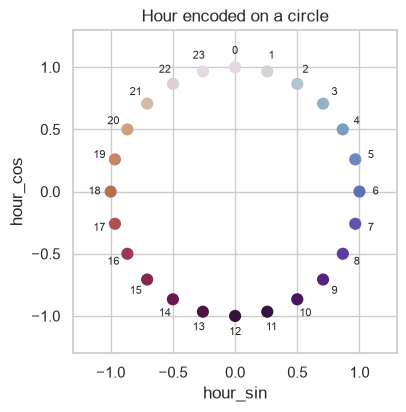

In [5]:
# ขั้น 5.4 — พิสูจน์ว่า sin/cos ทำให้ 23:00 กับ 0:00 อยู่ใกล้กันจริง (ตัวเลขดิบ 0–23 บอกว่าห่างกัน 23)
def circle_dist(a, b):
    # ระยะแบบยุคลิดระหว่างชั่วโมง a กับ b เมื่อวางบนวงกลม (sin, cos)
    return np.hypot(np.sin(2 * np.pi * a / 24) - np.sin(2 * np.pi * b / 24),
                    np.cos(2 * np.pi * a / 24) - np.cos(2 * np.pi * b / 24))


pairs = [(23, 0), (0, 1), (22, 2), (0, 12), (6, 18)]
dist_table = pd.DataFrame([{"คู่ชั่วโมง": f"{a}:00 - {b}:00", "|ต่าง| แบบตัวเลข 0-23": abs(a - b),
                            "ระยะบนวงกลม (sin, cos)": round(circle_dist(a, b), 3)} for a, b in pairs])
print(dist_table.to_string(index=False))

# วาด 24 ชั่วโมงบนวงกลม → เห็นว่าไม่มี "รอยต่อ" ระหว่าง 23 กับ 0
h = np.arange(24)
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.scatter(np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24), c=h, cmap="twilight", s=60)
for i in h:
    ax.annotate(str(i), (1.13 * np.sin(2 * np.pi * i / 24), 1.13 * np.cos(2 * np.pi * i / 24)), ha="center", va="center", fontsize=8)
ax.set(xlabel="hour_sin", ylabel="hour_cos", title="Hour encoded on a circle", xlim=(-1.3, 1.3), ylim=(-1.3, 1.3), aspect="equal")
savefig("05_hour_cyclic.png")
plt.show()

**ผลลัพธ์:**
- แบบตัวเลขดิบ 23:00 กับ 0:00 ห่างกัน **23** (ไกลที่สุดที่เป็นไปได้) ทั้งที่ห่างกันจริงแค่ 1 ชั่วโมง · แบบวงกลมได้ **0.261** เท่ากับคู่ 0:00–1:00 พอดี
- 22:00–2:00 (ห่างจริง 4 ชม.) ตัวเลขดิบบอก 20 แต่วงกลมบอก 1.0 · คู่ที่ห่างกันครึ่งวัน (0–12, 6–18) ได้ระยะมากสุด = 2 (เส้นผ่านศูนย์กลาง)
- กราฟวงกลมแสดงว่าทุกชั่วโมงเรียงต่อกันเป็นวง ไม่มี "รอยต่อ" ระหว่าง 23 กับ 0

**ข้อจำกัดของ sin/cos:** แก้ปัญหา "ระยะ" ได้ แต่สำหรับ **โมเดลเชิงเส้น** ผลรวม $a\cdot\text{hour\_sin} + b\cdot\text{hour\_cos}$ เป็นคลื่นที่มี **สูงสุดได้แค่ 1 ครั้งต่อวัน** ในขณะที่ยอดเช่าวันทำงานมี **2 พีค** (8:00 และ 18:00 — `01_eda` 4.5) → โมเดลเชิงเส้นจับรูปร่างนี้ไม่ได้ด้วย sin/cos อย่างเดียว

**ตัดสินใจ:** เก็บ encoding ของชั่วโมงไว้ 3 แบบ เลือกผ่านพารามิเตอร์ `hour=` ของ Pipeline (ขั้น 6) แล้วให้ CV ในขั้น 10 ตัดสิน
| โมเดล | `hour=` ที่คาดว่าเหมาะ | เหตุผล |
|---|---|---|
| Linear Regression / Lasso | `"onehot"` (24 คอลัมน์) | ให้แต่ละชั่วโมงมีค่าคงที่ของตัวเอง → รองรับ 2 พีคได้ |
| kNN | `"cyclic"` | ใช้ระยะทาง → ต้องการให้ 23:00 ใกล้ 0:00 และจำนวนคอลัมน์น้อย |
| Random Forest / Gradient Boosting | `"raw"` (0–23) | ต้นไม้ตัดแบ่ง `hour ≤ 7.5` ได้ตรงๆ หลายครั้ง จับ 2 พีคได้เอง |

### 5.5 กำหนด y (regression)
**โค้ดทำอะไร:**
- `y` = `rented_bike_count` ดิบ (คัน/ชม.) ไม่แปลงค่าใดๆ — label มากับ dataset อยู่แล้ว
- `y_test` แยกเก็บไว้เฉยๆ **ไม่พิมพ์/ไม่ดูค่า** จนถึงขั้น 13
- ดูสถิติของ `y_train` ทั้งหมดและแยกฤดู เพื่อรู้ "สเกล" ของ MAE ที่จะได้ (MAE 100 คัน ดีแค่ไหนขึ้นกับว่ายอดปกติเป็นหลักร้อยหรือหลักพัน)

In [6]:
# ขั้น 5.5 — กำหนด target y = จำนวนจักรยานที่ถูกเช่าต่อชั่วโมง (regression)
assert config.TASK == "regression"
y_train = train[config.TARGET_COL]
y_test = test[config.TARGET_COL]      # ไม่ดูค่าใดๆ ของ test จนถึงขั้น 13

print(f"y_train: {len(y_train):,} ค่า | mean = {y_train.mean():.1f} | median = {y_train.median():.1f} | "
      f"min = {y_train.min()} | max = {y_train.max()} คัน/ชม.")
print()
print("ค่าเฉลี่ย y_train แยกฤดู (คัน/ชม.):")
print(y_train.groupby(train["seasons"]).mean().round(1).sort_values().to_dict())

y_train: 6,672 ค่า | mean = 760.3 | median = 586.0 | min = 2 | max = 3556 คัน/ชม.

ค่าเฉลี่ย y_train แยกฤดู (คัน/ชม.):
{'Winter': 230.3, 'Spring': 773.9, 'Autumn': 966.9, 'Summer': 1056.0}


**ผลลัพธ์:**
- `y_train` 6,672 ค่า · mean = **760.3** · median = **586.0** · ช่วง 2–3,556 คัน/ชม. (หลังเพิ่มกฎวันพายุใน 5.2)
- ค่าเฉลี่ยแยกฤดู: Winter **230** · Spring 774 · Autumn 967 · Summer **1,056** คัน/ชม. → ต่างกันเกือบ 4.6 เท่า
  → `seasons`/`temp_c` จะเป็น feature ที่แรงมาก และค่าคลาดเคลื่อนเป็นคันของฤดูหนาวจะเล็กตามสเกล

**ผลต่อขั้นถัดไป:**
- เมตริกหลัก MAE (ขั้น 1) → ใน CV ใช้ `scoring="neg_mean_absolute_error"` (sklearn ให้ค่าติดลบเพื่อให้ "มากกว่า = ดีกว่า" ต้องกลับเครื่องหมายตอนรายงาน) คู่กับ `"neg_root_mean_squared_error"` และ `"r2"`
- เพราะ MAE ขึ้นกับสเกลของแต่ละฤดู ต้องรายงาน MAE แยกฤดูในขั้น error analysis (test มีฤดูหนาวมากกว่า train — `01_eda` 3.2)

### 5.6 ประกอบ X, y, groups + ตรวจ leakage
**โค้ดทำอะไร:**
- ตัดคอลัมน์ที่ห้ามเป็น feature ออกจาก X: `rented_bike_count` (target), `date` (ใช้เป็น `groups` แทน), `functioning_day` (หลังตัดเหลือค่าเดียว), `holiday` (ข้อความ แทนด้วย `is_holiday` แล้ว)
- `groups_train` = วันที่ของแต่ละแถวใน train → ใช้กับ `GroupKFold` ในทุกขั้นที่มี CV
- `assert` กัน leakage

In [7]:
# ขั้น 5.6 — ประกอบ X, y, groups และตรวจ leakage ก่อนเข้าโมเดล
# ตัดคอลัมน์ที่ห้ามเป็น feature: target เอง, date (ใช้เป็น group), functioning_day (ถูกกรองแล้ว), holiday (แปลงเป็น is_holiday แล้ว)
NOT_FEATURES = [config.TARGET_COL, "date", "functioning_day", "holiday"]
FEATURES = [c for c in train.columns if c not in NOT_FEATURES]

X_train, X_test = train[FEATURES], test[FEATURES]
groups_train = train["date"]          # บอก GroupKFold ว่าแถวไหนเป็นวันเดียวกัน → วันเดียวกันอยู่ fold เดียวกัน

assert config.TARGET_COL not in X_train.columns and "date" not in X_train.columns
assert list(X_train.columns) == list(X_test.columns)
assert len(X_train) == len(y_train) == len(groups_train)
assert X_train.index.equals(y_train.index) and X_train.index.equals(groups_train.index)
assert X_test.index.equals(y_test.index)
assert set(groups_train) <= set(train_dates) and set(test["date"]) <= set(test_dates)
assert not set(groups_train) & set(test["date"])
assert not set(storm_dates) & (set(groups_train) | set(test["date"]))
assert config.STORM_DATES == tuple(pd.to_datetime(storm_dates).strftime("%Y-%m-%d"))

print(f"X_train: {X_train.shape} | y_train: {y_train.shape} | groups: {groups_train.nunique()} วัน")
print(f"X_test : {X_test.shape}")
print("features:", FEATURES)
X_train.dtypes.value_counts()

X_train: (6672, 18) | y_train: (6672,) | groups: 278 วัน
X_test : (1656, 18)
features: ['hour', 'temp_c', 'humidity_pct', 'wind_speed_ms', 'visibility_10m', 'dew_point_c', 'solar_radiation_mj', 'rainfall_mm', 'snowfall_cm', 'seasons', 'day_of_week', 'is_weekend', 'is_holiday', 'month', 'hour_sin', 'hour_cos', 'is_raining', 'rain_prev_3h']


float64    10
int64       5
int32       2
object      1
Name: count, dtype: int64

**ผลลัพธ์:**
- X_train **6,672 × 18** (feature ดิบ 10 ตัว + ใหม่ 8 ตัว) · X_test 1,656 × 18 คอลัมน์ชุดเดียวกัน · groups = 278 วัน
- 18 feature: `hour`, อากาศ 8 ตัว, `seasons` + 8 ตัวที่สร้างใหม่ · มี `seasons` เป็น object ตัวเดียว ที่เหลือเป็นตัวเลข
- ยังไม่มีการ scale/encode ใดๆ ในขั้นนี้ — ทุกอย่างที่ "เรียนจากข้อมูล" จะอยู่ใน Pipeline (ขั้น 6)

**เช็คลิสต์ leakage ที่ผ่านแล้วในขั้น 5**
- [x] y = ยอดเช่าดิบ ไม่มีการแปลงที่เรียนค่าจากข้อมูล (ถ้าจะลอง `log1p` ในขั้น 11 จะอยู่ใน `TransformedTargetRegressor` ซึ่ง fit ใหม่ทุก fold)
- [x] `rented_bike_count` ไม่อยู่ใน X
- [x] ไม่มี feature ที่คำนวณจาก target (feature ปฏิทิน/อากาศมาจากแถวเดียวกัน; ฝนย้อนหลังมาจากชั่วโมงก่อนหน้าในวันเดียวกัน ไม่แตะยอดเช่า)
- [x] ไม่ได้ดูค่าใดๆ ของ test นอกจากจำนวนแถว
- [x] train/test ยังอยู่ในรายการวันของ split เดิม แต่ไม่มีวันพายุตามกฎภายนอก และ index ของ X/y/groups ตรงกัน

---
## ขั้น 6 — Preprocessing ใน Pipeline

**หลักการ:** ทุกขั้นที่ "เรียนค่าจากข้อมูล" (ค่ามัธยฐานของ imputer, mean/std ของ scaler, รายการหมวดหมู่ของ encoder และต่อไปคือ selector, PCA) ต้องอยู่ใน `Pipeline`
เพราะตอน `cross_validate(pipe, ..., cv=GroupKFold)` sklearn จะ `fit` ทั้ง pipeline ใหม่บน training fold แล้วค่อย `transform` validation fold → ค่าสถิติไม่รั่วจาก validation เข้ามา
ถ้า scale ทั้ง train ก่อนแล้วค่อย CV → mean/std มีข้อมูลของ validation fold ปนอยู่ = leakage (เล็กแต่มีจริง)

### 6.1 แบ่งกลุ่มคอลัมน์
**โค้ดทำอะไร:** กำหนดว่าแต่ละคอลัมน์จะถูกจัดการแบบไหน

| กลุ่ม | คอลัมน์ | การแปลง | เหตุผล |
|---|---|---|---|
| ตัวเลข (อากาศ/ประวัติฝน) | 9 ตัว | median imputer → StandardScaler | `humidity_pct` มี NaN 17 ค่า (missing 9 + 0% 8), `dew_point_c` 5 และ `temp_c` 1 จากกฎเซนเซอร์ในขั้น 5.2 → เติมด้วย median · สเกลต่างกันมาก (visibility 27–2,000) |
| ชั่วโมง (cyclic) | `hour_sin`, `hour_cos` | StandardScaler | ให้อยู่สเกลเดียวกับตัวอื่น |
| binary | `is_weekend`, `is_holiday`, `is_raining` | StandardScaler | ให้ L1 (ขั้น 7) ลงโทษทุก feature ในสเกลเดียวกัน และ kNN ให้น้ำหนักเท่ากัน |
| หมวดหมู่ | `seasons`, `month`, `day_of_week` | OneHotEncoder | ไม่มีลำดับเชิงตัวเลขที่มีความหมาย (เดือน 12 ไม่ได้ "มากกว่า" เดือน 1 และธ.ค. อยู่ติด ม.ค.) |

`rain_prev_3h` เป็นตัวเลขที่ผ่าน median imputer/scaler ชุดเดียวกับอากาศ; ตารางนี้เป็นกรณีเก็บ feature ตามผลใน 5.3.1

In [8]:
# ขั้น 6.1 — แบ่งคอลัมน์ตามวิธี preprocess ที่ต้องใช้ (ตัวเลข → impute + scale · หมวดหมู่ → one-hot)
WEATHER_COLS = ["temp_c", "humidity_pct", "wind_speed_ms", "visibility_10m", "dew_point_c",
                "solar_radiation_mj", "rainfall_mm", "snowfall_cm"]
CYCLIC_COLS = ["hour_sin", "hour_cos"]
BINARY_COLS = ["is_weekend", "is_holiday", "is_raining"]
CAT_COLS = ["seasons", "month", "day_of_week"]   # หมวดหมู่ที่ไม่มีลำดับ → one-hot ไม่ใช่ label encoding

RAIN_HISTORY_COLS = ["rain_prev_3h"] if USE_RAIN_HISTORY else []

grouped = WEATHER_COLS + RAIN_HISTORY_COLS + CYCLIC_COLS + BINARY_COLS + CAT_COLS
print("ใน X แต่ไม่อยู่ในกลุ่มใด:", sorted(set(FEATURES) - set(grouped)))
assert set(grouped) <= set(FEATURES)

ใน X แต่ไม่อยู่ในกลุ่มใด: ['hour']


**ผลลัพธ์:** ทุกคอลัมน์ในกลุ่มมีอยู่ใน X จริง และเหลือ `hour` (ดิบ) ตัวเดียวที่ไม่อยู่ในกลุ่ม default — ตั้งใจ เพราะใช้ `hour_sin/cos` แทน · `hour` ดิบจะถูกใช้เมื่อเลือก `hour="raw"` หรือ `"onehot"` ในขั้นถัดไป

### 6.2 ฟังก์ชันสร้าง preprocessor และ Pipeline
**โค้ดทำอะไร:**
- `make_preprocessor(hour=...)` สร้าง `ColumnTransformer` ตามตาราง 6.1 โดยเลือกวิธี encode ชั่วโมงได้ 3 แบบ: `"cyclic"` (default), `"raw"` (0–23 ตรงๆ สำหรับ tree), `"onehot"` (24 คอลัมน์)
- `SimpleImputer(strategy="median")` เติม NaN ของความชื้น อุณหภูมิ และ dew point จากขั้น 5.2 ด้วยมัธยฐานของ training fold
- `make_pipeline(model, select=..., hour=...)` ต่อเป็น `Pipeline([("pre", ...), ("select", ...), ("model", ...)])`
  - ช่อง `"select"` เป็น `"passthrough"` ไว้ก่อน → ขั้น 7 ใส่ `SelectKBest` / `RFE` / `SelectFromModel` ลงช่องนี้ และขั้น 8 ใส่ PCA
  - ขั้น 10 แค่เปลี่ยน `model` ก็เทียบหลายโมเดลด้วย preprocessing ชุดเดียวกันได้
- `OneHotEncoder(handle_unknown="ignore")`: ถ้า validation/test มีหมวดที่ training fold ไม่เคยเห็น จะได้ศูนย์ทั้งแถวแทนที่จะ error
- `verbose_feature_names_out=False` ให้ชื่อ feature หลังแปลงสั้น อ่านง่าย (เช่น `seasons_Winter` แทน `cat__seasons_Winter`)
- `rain_history=False` ทำให้ preprocessor ไม่นำ rain_prev_3h เข้าโมเดล สำหรับเทียบกับ baseline ที่ใช้แถว/พารามิเตอร์/folds เดียวกันใน 5.3.1 · ค่า default ใช้ผลเลือก feature ของรอบนี้

In [9]:
# ขั้น 6.2 — ฟังก์ชันสร้าง preprocessor และ Pipeline
# แนวคิดหลัก: ทุกอย่างที่ "เรียนค่าจากข้อมูล" (median, mean/std, หมวดหมู่) อยู่ใน Pipeline
# → ตอน CV จะ fit ใหม่บน training fold เท่านั้น ข้อมูล validation/test ไม่รั่วเข้าไป
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_preprocessor(hour="cyclic", *, rain_history=USE_RAIN_HISTORY):
    # hour= เลือกวิธี encode ชั่วโมงตามชนิดโมเดล: cyclic (kNN), raw (tree), onehot (linear)
    hour_num = {"cyclic": CYCLIC_COLS, "raw": ["hour"], "onehot": []}[hour]
    hour_cat = ["hour"] if hour == "onehot" else []
    weather = WEATHER_COLS + (["rain_prev_3h"] if rain_history else [])
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median")),   # median ทนต่อค่าสุดโต่งมากกว่า mean
        ("scale", StandardScaler()),                    # Z-score: ให้ทุกตัวแปรมีสเกลเท่ากัน (สำคัญกับ kNN, PCA, Lasso)
    ])
    return ColumnTransformer([
        ("num", numeric, weather + hour_num + BINARY_COLS),
        # handle_unknown="ignore": ถ้าเจอหมวดที่ไม่เคยเห็นตอนฝึก ให้เป็นศูนย์ทุกคอลัมน์แทนการ error
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS + hour_cat),
    ], verbose_feature_names_out=False)


def make_pipeline(model, select="passthrough", hour="cyclic", *, rain_history=USE_RAIN_HISTORY):
    # 3 ช่อง: preprocess → select (feature selection หรือ PCA, ขั้น 7–8) → model
    return Pipeline([
        ("pre", make_preprocessor(hour, rain_history=rain_history)),
        ("select", select),
        ("model", model),
    ])


# ตัวอย่างโครงสร้าง (model จริงเลือกในขั้น 9-10)
from sklearn.linear_model import LinearRegression
make_pipeline(LinearRegression())

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['temp_c', 'humidity_pct',
                                                   'wind_speed_ms',
                                                   'visibility_10m',
                                                   'dew_point_c',
                                                   'solar_radiation_mj',
                                                   'rainfall_mm', 'snowfall_cm',
                                                   'rain_prev_3h', 'hour_sin',
                                                   'hour_cos', 

**ผลลัพธ์:** โครงสร้าง Pipeline มี 3 ช่องตามที่ออกแบบ: `pre` (ColumnTransformer: `num` = imputer → scaler, `cat` = one-hot) → `select` (passthrough) → `model`
LinearRegression ในที่นี้เป็นแค่ตัวอย่างให้เห็นโครงสร้าง ยังไม่ได้ fit

### 6.3 ตรวจผลลัพธ์ของ preprocessor
**โค้ดทำอะไร:** `fit_transform` preprocessor บน X_train ทั้งก้อน **เพื่อตรวจความถูกต้องเท่านั้น** (ขั้นประเมินจริงใช้ CV ที่ fit ใหม่ในแต่ละ fold)
- จำนวนคอลัมน์หลังแปลง + รายชื่อ
- มี NaN เหลือไหม, ค่ามัธยฐานที่ imputer ใช้เติมความชื้น
- คอลัมน์ตัวเลขหลัง scale ต้องมี mean ≈ 0, std ≈ 1 · one-hot ของแต่ละกลุ่มต้องรวมกันได้ 1 ทุกแถว

In [10]:
# ขั้น 6.3 — ลอง fit preprocessor บน train แล้วตรวจผล: ไม่มี NaN เหลือ, one-hot ถูก, ตัวเลขถูก standardize
pre = make_preprocessor()
Xt = pd.DataFrame(pre.fit_transform(X_train), columns=pre.get_feature_names_out(), index=X_train.index)

num_out = WEATHER_COLS + RAIN_HISTORY_COLS + CYCLIC_COLS + BINARY_COLS
imputer = pre.named_transformers_["num"].named_steps["impute"]
print(f"shape หลังแปลง: {Xt.shape} | NaN เหลือ: {int(Xt.isna().sum().sum())}")
print("ค่าที่ใช้เติม humidity_pct (median ของ train):", imputer.statistics_[WEATHER_COLS.index("humidity_pct")])
# one-hot ที่ถูกต้อง: แต่ละแถวต้องมีเลข 1 แค่ช่องเดียวในกลุ่มของมัน
for c in CAT_COLS:
    cols = [n for n in Xt.columns if n.startswith(c + "_")]
    print(f"{c:<12} -> {len(cols):>2} คอลัมน์ | ผลรวมต่อแถว = 1 ทุกแถว: {bool((Xt[cols].sum(axis=1) == 1).all())}")
print("\nfeature หลังแปลง:", list(Xt.columns))
Xt[num_out].agg(["mean", "std"]).T.round(3).T     # หลัง StandardScaler: mean ≈ 0, std ≈ 1

shape หลังแปลง: (6672, 37) | NaN เหลือ: 0


ค่าที่ใช้เติม humidity_pct (median ของ train): 57.0
seasons      ->  4 คอลัมน์ | ผลรวมต่อแถว = 1 ทุกแถว: True
month        -> 12 คอลัมน์ | ผลรวมต่อแถว = 1 ทุกแถว: True
day_of_week  ->  7 คอลัมน์ | ผลรวมต่อแถว = 1 ทุกแถว: True

feature หลังแปลง: ['temp_c', 'humidity_pct', 'wind_speed_ms', 'visibility_10m', 'dew_point_c', 'solar_radiation_mj', 'rainfall_mm', 'snowfall_cm', 'rain_prev_3h', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday', 'is_raining', 'seasons_Autumn', 'seasons_Spring', 'seasons_Summer', 'seasons_Winter', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6']


,temp_c,humidity_pct,wind_speed_ms,visibility_10m,dew_point_c,solar_radiation_mj,rainfall_mm,snowfall_cm,rain_prev_3h,hour_sin,hour_cos,is_weekend,is_holiday,is_raining
mean,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**ผลลัพธ์:**
- ได้ **37 คอลัมน์**: ตัวเลข 14 (อากาศ 8 + ประวัติฝน 1 + ชั่วโมง 2 + binary 3) + one-hot 23 (`seasons` 4 + `month` 12 + `day_of_week` 7) · ไม่มี NaN เหลือ
- NaN ของความชื้น 17, dew point 5 และอุณหภูมิ 1 ค่า ถูกเติมด้วย median ของ train ในการสาธิตนี้; median ความชื้น = **57%** · ตอน CV จะ fit imputer ใหม่ในแต่ละ training fold
- one-hot ทุกกลุ่มรวมกันได้ 1 ทุกแถว (แต่ละแถวอยู่ในฤดู/เดือน/วันเดียวพอดี)
- คอลัมน์ตัวเลข 14 ตัวมี mean = 0.000 และ std = 1.000 → StandardScaler ทำงานถูกต้อง (สเกลของ visibility กับ rainfall เท่ากันแล้ว)
- ⚠️ one-hot ของ `seasons` กับ `month` ซ้อนกันสมบูรณ์ (รู้เดือน = รู้ฤดู) และแต่ละกลุ่ม one-hot รวมกันได้ 1 เท่ากับ intercept → **multicollinearity สมบูรณ์** สำหรับ Linear Regression ที่ไม่มี regularization: ค่าทำนายยังใช้ได้ (sklearn แก้ด้วย least squares แบบ minimum-norm) แต่ **coefficient ไม่มีคำตอบเดียว จึงตีความไม่ได้** → เป็นเหตุผลที่ต้องทำ feature selection ในขั้น 7 (เลือก `seasons` หรือ `month` อย่างใดอย่างหนึ่ง) และใช้ Lasso ซึ่งมี regularization

### 6.4 พิสูจน์ว่า Pipeline + GroupKFold ไม่รั่ว
**โค้ดทำอะไร:** จำลองสิ่งที่ `cross_validate` จะทำในขั้น 10 ทีละ fold ด้วย `GroupKFold(n_splits=5)` + `groups=groups_train`
- นับวันที่อยู่ทั้งใน training fold และ validation fold (ต้องเป็น 0)
- fit preprocessor ใหม่บน training fold แล้วดูค่าที่มัน "เรียน" (mean ของ `temp_c` ใน scaler, median ความชื้นใน imputer) → ต้อง **ต่างกันในแต่ละ fold** = แต่ละ fold เรียนจากข้อมูลของตัวเองเท่านั้น
- เทียบกับ `KFold` ธรรมดา (สุ่มทีละแถว ไม่ส่ง groups) ว่ามีวันซ้ำกี่วัน

In [11]:
# ขั้น 6.4 — พิสูจน์ว่า Pipeline + GroupKFold ไม่รั่ว โดยจำลองสิ่งที่ cross_validate ทำทีละ fold
from sklearn.model_selection import GroupKFold, KFold

cv = GroupKFold(n_splits=5)   # ใช้ตัวนี้ในทุกขั้นที่มี CV (ขั้น 7-11) และต้องส่ง groups= ทุกครั้ง

rows = []
for k, (tr, va) in enumerate(cv.split(X_train, y_train, groups=groups_train)):
    p = make_preprocessor().fit(X_train.iloc[tr])     # fit ใหม่บน training fold เท่านั้น
    num = p.named_transformers_["num"]
    rows.append({
        "fold": k,
        "train วัน": groups_train.iloc[tr].nunique(),
        "val วัน": groups_train.iloc[va].nunique(),
        "วันซ้ำ train-val": len(set(groups_train.iloc[tr]) & set(groups_train.iloc[va])),   # ต้องเป็น 0
        # ค่าที่ preprocessor เรียนได้ต่างกันในแต่ละ fold = แต่ละ fold เรียนจากข้อมูลของตัวเอง
        "scaler mean temp_c": num.named_steps["scale"].mean_[WEATHER_COLS.index("temp_c")],
        "imputer median humidity": num.named_steps["impute"].statistics_[WEATHER_COLS.index("humidity_pct")],
        "y เฉลี่ยใน val": y_train.iloc[va].mean(),
    })
fold_table = pd.DataFrame(rows).set_index("fold").round(3)

# เทียบกับ KFold ธรรมดา (สุ่มทีละแถว ไม่ส่ง groups) → ชั่วโมงของวันเดียวกันไปอยู่ทั้ง train และ val
tr, va = next(KFold(n_splits=5, shuffle=True, random_state=config.RANDOM_STATE).split(X_train))
leak_days = len(set(groups_train.iloc[tr]) & set(groups_train.iloc[va]))
print(f"KFold ธรรมดา fold 0: val มี {groups_train.iloc[va].nunique()} วัน -> ซ้ำกับ train {leak_days} วัน")
fold_table

KFold ธรรมดา fold 0: val มี 277 วัน -> ซ้ำกับ train 277 วัน


,train วัน,val วัน,วันซ้ำ train-val,scaler mean temp_c,imputer median humidity,y เฉลี่ยใน val
fold,,,,,,
0,222,56,0,13.345,57.0,741.240
1,222,56,0,13.265,57.0,814.811
2,222,56,0,13.288,57.0,741.305
3,223,55,0,13.208,58.0,766.535
4,223,55,0,13.295,57.0,737.402


**ผลลัพธ์:**
- `GroupKFold`: ทุก fold มี **วันซ้ำ train-val = 0** · train 222–223 วัน / validation 55–56 วัน
- mean อุณหภูมิของ scaler ต่างกันตาม fold (13.21–13.35 °C); median ความชื้น 57–58% → preprocessor fit ใหม่บน training fold
- ยอดเฉลี่ย validation 737–815 คัน/ชม. เทียบกับ train ทั้งหมด 760.3 · วัน/ฤดูของแต่ละ fold ต่างกัน จึงต้องรายงาน std ของ CV
- `KFold` ธรรมดา fold 0 มีวันจาก validation ซ้ำ train **277 วัน** → ใช้เป็นตัวอย่าง leakage เท่านั้น; ทุก CV ที่ประเมินโมเดลใช้ `GroupKFold` พร้อม `groups=`

### 5.3.1 ตรวจผลของ rain_prev_3h หลังนิยาม Pipeline
**โค้ดทำอะไร:** เทียบ HGB ค่า default สองกรณีบน train ที่ผ่าน scope rules แล้ว ใช้ GroupKFold(5), groups=date และ folds เดียวกัน โดย median imputer/scaler/encoder ถูก fit ใหม่ในแต่ละ training fold
- พารามิเตอร์ HGB และทุก feature เดิมเท่ากัน เปลี่ยนเฉพาะว่าจะส่ง rain_prev_3h เข้า preprocessor หรือไม่ · ยังไม่ใช้ test และยังไม่ tune
- แสดง MAE ทั้ง 5 folds และ mean/std · เก็บเมื่อ mean CV MAE ต่ำลงตามเกณฑ์ที่กำหนดไว้ แล้วยืนยันว่า USE_RAIN_HISTORY ที่ส่งต่อใน notebook ตรงกับผลนี้


In [12]:
# ขั้น 5.3.1 — เทียบ HGB ด้วย folds เดียวกันบน train เพื่อเลือกฝนย้อนหลัง โดยไม่ใช้ผล test หรือปรับพารามิเตอร์
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate

rain_cv_rows = []
rain_cv_folds = {}
for name, include in [("Without rain history", False), ("With rain_prev_3h", True)]:
    candidate = make_pipeline(HistGradientBoostingRegressor(random_state=config.RANDOM_STATE),
                              hour="raw", rain_history=include)
    scores = cross_validate(candidate, X_train, y_train, groups=groups_train, cv=cv,
                            scoring="neg_mean_absolute_error", n_jobs=1)
    fold_mae = -scores["test_score"]
    rain_cv_folds[name] = fold_mae
    rain_cv_rows.append({"candidate": name, "CV MAE": fold_mae.mean(), "std": fold_mae.std()})
rain_feature_cv = pd.DataFrame(rain_cv_rows).set_index("candidate")
rain_fold_cv = pd.DataFrame(rain_cv_folds)
rain_fold_cv["improvement"] = rain_fold_cv["Without rain history"] - rain_fold_cv["With rain_prev_3h"]
rain_keep_from_cv = bool(rain_feature_cv.loc["With rain_prev_3h", "CV MAE"] <
                         rain_feature_cv.loc["Without rain history", "CV MAE"])
print(rain_feature_cv.round(3).to_string())
print("\nMAE ราย fold (improvement บวก = feature ใหม่ดีกว่า):")
print(rain_fold_cv.round(3).to_string(index=False))
print("เก็บ rain_prev_3h จาก train CV:", rain_keep_from_cv)
assert USE_RAIN_HISTORY == rain_keep_from_cv, "ผล CV ไม่สนับสนุน flag ที่ส่งต่อ: ทบทวนบน train ก่อนขั้นเลือกโมเดล"
assert (train.loc[train["hour"].eq(0), "rain_prev_3h"] == 0).all()


                       CV MAE    std
candidate                           
Without rain history  112.153  4.232
With rain_prev_3h     109.183  2.927

MAE ราย fold (improvement บวก = feature ใหม่ดีกว่า):
 Without rain history  With rain_prev_3h  improvement
              114.259            107.679        6.580
              118.982            113.914        5.068
              111.450            110.893        0.556
              109.472            107.961        1.511
              106.602            105.470        1.132
เก็บ rain_prev_3h จาก train CV: True


**ผลลัพธ์:**
- HGB default ไม่ใช้ฝนย้อนหลัง: CV MAE **112.153 ± 4.232** · ใช้ `rain_prev_3h`: **109.183 ± 2.927** คัน/ชม.
- MAE เฉลี่ยลด **2.970** คัน/ชม. และลดใน **5/5 folds** · แถว train, พารามิเตอร์ HGB และ GroupKFold เดียวกัน; ใช้ test เพียงประเมินหลังเลือกโมเดลในขั้น 13

**ตัดสินใจ:** เก็บ `rain_prev_3h` ตามเกณฑ์ train CV และส่งผ่าน imputer/scaler ของ Pipeline ให้ทุกโมเดล · ให้ FS ของแต่ละโมเดลใน PR ถัดไปเลือกว่าจะเก็บคอลัมน์นี้ · ผลนี้สนับสนุนประโยชน์ต่อการทำนาย แต่ไม่ได้ยืนยันสาเหตุเรื่องถนนเปียก

### 6.5 โมเดลไหนต้อง scale
| model family | ต้อง scale ไหม | เพราะ |
|---|---|---|
| kNN, SVR | **ต้อง** | ใช้ระยะทาง → คอลัมน์สเกลใหญ่ (visibility 27–2,000) ครอบงำระยะ |
| Lasso / Ridge | **ต้อง** | regularization ลงโทษขนาด coefficient ซึ่งขึ้นกับสเกลของ feature → ไม่ scale = ลงโทษไม่เท่ากัน |
| Linear Regression (ไม่มี regularization) | ไม่จำเป็นต่อค่าทำนาย | ค่าทำนายเท่าเดิม แต่ต้อง scale ถ้าจะเทียบขนาด coefficient ว่า feature ไหนสำคัญกว่า |
| Decision Tree, Random Forest, Gradient Boosting | ไม่จำเป็น | ตัดแบ่งทีละ feature ด้วย threshold → การ scale แบบ monotonic ไม่เปลี่ยนลำดับค่า ผลเหมือนเดิม |

→ ใส่ scaler ไว้ในทุก pipeline (ไม่เสียหายกับ tree และทำให้ทุกโมเดลได้ input ชุดเดียวกัน เทียบกันได้ยุติธรรม)

---
### สรุปขั้น 5–6 (สิ่งที่ส่งต่อไปขั้น 7+)
| ตัวแปร / ฟังก์ชัน | คืออะไร |
|---|---|
| `X_train`, `y_train`, `groups_train` | 6,672 แถว × 18 feature, y = `rented_bike_count` (คัน/ชม.), วันที่สำหรับ GroupKFold |
| `X_test`, `y_test` | 1,656 แถว — **ห้ามใช้จนถึงขั้น 13** |
| `make_pipeline(model, select, hour, rain_history=USE_RAIN_HISTORY)` | Pipeline มาตรฐาน: imputer + scaler + one-hot → ช่อง select → model |
| `cv` | `GroupKFold(n_splits=5)` — ใช้คู่กับ `groups=groups_train` เสมอ |

**เช็คลิสต์ leakage (สถานะหลังขั้น 6)**
- [x] split ตามวัน และ CV ใช้ `GroupKFold` + ส่ง `groups=`
- [x] y = ยอดเช่าดิบ (ไม่มี threshold / การแปลงที่เรียนจากข้อมูล)
- [x] `rented_bike_count` ไม่อยู่ใน X
- [x] imputer / scaler / encoder อยู่ใน Pipeline (selector / PCA จะใส่ในช่อง `select` ขั้น 7–8)
- [x] ไม่มี feature ที่คำนวณจาก target
- [x] ไม่ได้เปิด test ระหว่างขั้น 4–6

---
## ขั้น 7 — Feature selection 3 แบบ

**หลักการ:** selector ทุกตัวอยู่ในช่อง `select` ของ Pipeline และเลือกจำนวน feature / ค่า alpha ด้วย `GridSearchCV` + `GroupKFold` + `groups` → การเลือก feature ถูกทำใหม่ในทุก fold จากข้อมูล training fold เท่านั้น
รอบนี้ประเมินด้วย **Linear Regression + `hour="onehot"`** (59 คอลัมน์) · ผลของขั้นนี้เป็นของ Linear เท่านั้น; การทดลอง FS แยก kNN/RF/HGB จะเพิ่มใน PR ถัดไปตามลำดับงาน

### 7.0 ฟังก์ชันช่วย + จุดอ้างอิง (ทุก feature)
**โค้ดทำอะไร:**
- `cv_report(pipe, name)` = `cross_validate` ด้วย `cv` + `groups=groups_train` แล้วคืน MAE (mean ± std) / MSE / RMSE / R² + MAE บน train + เวลา fit — ใช้ซ้ำทุกขั้นจากนี้
- `grid(pipe, params)` = `GridSearchCV` ที่ตั้งค่าเหมือนกันทุกครั้ง (`GroupKFold`, `groups`, เลือกด้วย MAE)
- วัด Linear Regression ที่ใช้ทุก feature เป็นจุดอ้างอิงของขั้นนี้

In [13]:
# ขั้น 7.0 — ฟังก์ชันช่วยที่ใช้ซ้ำทุกขั้นจากนี้ + จุดอ้างอิง (Linear Regression ใช้ทุก feature)
import time
from functools import partial

from sklearn.feature_selection import RFE, SelectFromModel, SelectKBest, f_regression, mutual_info_regression
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, cross_validate

# วัดครบ 4 metric ของ regression ตามโจทย์ · sklearn ให้คะแนนแบบ "ยิ่งมากยิ่งดี" จึงเป็นค่าติดลบ (ต้องกลับเครื่องหมาย)
SCORING = {"MAE": "neg_mean_absolute_error", "MSE": "neg_mean_squared_error",
           "RMSE": "neg_root_mean_squared_error", "R2": "r2"}


def cv_report(pipe, name):
    """cross_validate ด้วย GroupKFold + groups แล้วคืน 1 แถว: mean ± std ของ MAE, mean ของ MSE/RMSE/R², MAE บน train, เวลา fit"""
    # return_train_score=True → ได้ MAE บน training fold ด้วย ใช้เทียบหา overfit (gap = CV − train)
    s = cross_validate(pipe, X_train, y_train, groups=groups_train, cv=cv, scoring=SCORING,
                       return_train_score=True, n_jobs=-1)
    return {
        "model": name,
        "MAE": -s["test_MAE"].mean(), "MAE_std": s["test_MAE"].std(),
        "MSE": -s["test_MSE"].mean(), "RMSE": -s["test_RMSE"].mean(), "R2": s["test_R2"].mean(),
        "MAE_train": -s["train_MAE"].mean(), "fit_s": s["fit_time"].mean(),
    }


def grid(pipe, param_grid):
    """GridSearchCV แบบเดียวกันทุกขั้น: GroupKFold + groups, เลือกด้วย MAE"""
    # เลือกพารามิเตอร์ด้วย CV บน train เท่านั้น — test ยังไม่ถูกแตะ
    gs = GridSearchCV(pipe, param_grid, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
    return gs.fit(X_train, y_train, groups=groups_train)


# รอบนี้ขั้น 7 ยังประเมิน FS กับ Linear + hour one-hot; จะเพิ่มการทดลองแยกทุกโมเดลใน PR ถัดไป
base_lin = cv_report(make_pipeline(LinearRegression(), hour="onehot"), "Linear (ทุก feature)")
n_all = make_preprocessor("onehot").fit(X_train).get_feature_names_out().size
print(f"จำนวน feature หลัง preprocess (hour one-hot): {n_all}")
print(f"Linear Regression ทุก feature: CV MAE = {base_lin['MAE']:.1f} ± {base_lin['MAE_std']:.1f} คัน/ชม. | MAE บน train = {base_lin['MAE_train']:.1f} | R² = {base_lin['R2']:.3f}")

จำนวน feature หลัง preprocess (hour one-hot): 59
Linear Regression ทุก feature: CV MAE = 262.5 ± 3.7 คัน/ชม. | MAE บน train = 257.3 | R² = 0.721


**ผลลัพธ์:**
- `hour="onehot"` ได้ **59 คอลัมน์** (ตัวเลข 12 + seasons 4 + month 12 + day_of_week 7 + hour 24)
- Linear ทุก feature: CV MAE **262.5 ± 3.7**, train MAE **257.3** · gap 5.2 คัน/ชม. ยังเล็กสำหรับชุดนี้
- train มี **6,672 แถว** เทียบกับ 59 คอลัมน์ · ขั้นนี้ตรวจผล FS กับ Linear เท่านั้น ยังใช้สรุปแทน kNN/RF/HGB ไม่ได้

### 7.1 Filter — `f_regression` และ `mutual_info_regression`
| วิธี | วัดอะไร | จุดอ่อน |
|---|---|---|
| `f_regression` | F-statistic ของความสัมพันธ์ **เชิงเส้น** ระหว่างแต่ละ feature กับ y | มองไม่เห็นความสัมพันธ์โค้ง |
| `mutual_info_regression` | ข้อมูลร่วม (ความสัมพันธ์ **แบบใดก็ได้**) | ช้ากว่า มีการสุ่ม (ตั้ง `random_state`) |

- ⚠️ **ใช้ `chi2` (ที่ตัวอย่างในโจทย์ใช้) ไม่ได้** — chi² ต้องการ target เป็นหมวดหมู่ ส่วน y ของเราเป็นจำนวนต่อเนื่อง
- ทั้งสองวิธีให้คะแนน feature **ทีละตัว** แล้ว `SelectKBest` เก็บ `k` ตัวที่คะแนนสูงสุด · ลอง k = 5, 10, 15, 20, 30, 40, 58

CV MAE (คัน/ชม.) ตามจำนวน feature ที่เลือก (k):
    f_regression  mutual_info
k                            
5          361.5        366.5
10         353.9        354.3
15         318.8        345.5
20         303.2        318.3
30         280.2        289.5
40         263.5        271.0
59         262.5        262.5
f_regression  best k = 59 | MAE = 262.5
mutual_info   best k = 59 | MAE = 262.5


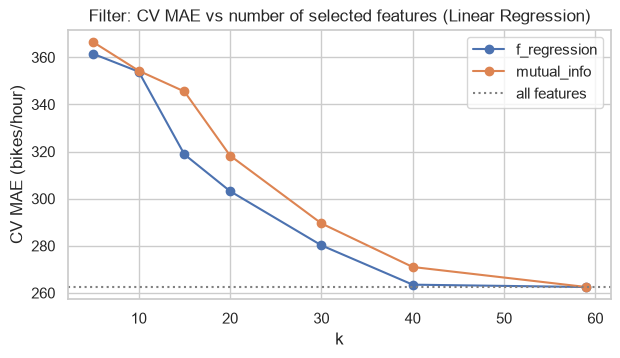

In [14]:
# ขั้น 7.1 — Filter: ให้คะแนน feature ทีละตัวด้วยสถิติ แล้วเก็บ k ตัวที่คะแนนสูงสุด
# ใช้ f_regression (ความสัมพันธ์เชิงเส้น) และ mutual_info (ความสัมพันธ์แบบใดก็ได้) แทน chi² ซึ่งใช้ได้กับ target หมวดหมู่เท่านั้น
K_GRID = [5, 10, 15, 20, 30, 40, n_all]
mi = partial(mutual_info_regression, random_state=config.RANDOM_STATE)   # MI มีการสุ่ม → ตรึง seed
# selector อยู่ในช่อง select ของ Pipeline → เลือก feature ใหม่ทุก fold จาก training fold เท่านั้น
filters = {
    "f_regression": grid(make_pipeline(LinearRegression(), select=SelectKBest(f_regression), hour="onehot"), {"select__k": K_GRID}),
    "mutual_info": grid(make_pipeline(LinearRegression(), select=SelectKBest(mi), hour="onehot"), {"select__k": K_GRID}),
}
k_table = pd.DataFrame({name: -gs.cv_results_["mean_test_score"] for name, gs in filters.items()}, index=K_GRID).round(1)
k_table.index.name = "k"
print("CV MAE (คัน/ชม.) ตามจำนวน feature ที่เลือก (k):")
print(k_table)
for name, gs in filters.items():
    print(f"{name:<13} best k = {gs.best_params_['select__k']:>2} | MAE = {-gs.best_score_:.1f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
k_table.plot(ax=ax, marker="o")
ax.axhline(base_lin["MAE"], color="gray", ls=":", label="all features")
ax.set(title="Filter: CV MAE vs number of selected features (Linear Regression)", xlabel="k", ylabel="CV MAE (bikes/hour)")
ax.legend()
savefig("07_filter_k.png")
plt.show()

**ผลลัพธ์:**
- ทั้ง f_regression และ MI ได้ **best k = 59** · k=5 ให้ MAE 361.5 / 366.5; k=40 ให้ 263.5 / 271.0; ใช้ทุกตัวได้ 262.5
- (อนุมาน) one-hot ของชั่วโมงมีประโยชน์ร่วมกันในการสร้างรูปร่างรายวัน การให้คะแนนทีละคอลัมน์แล้วตัดหลายตัวทำให้ Linear สูญเสียข้อมูลเวลา

**โค้ดทำอะไร (ถัดไป):** ดูอันดับ F/MI บน train ทั้งหมดเพื่ออธิบายเท่านั้น; selector ที่ใช้ประเมินถูก fit ใน Pipeline ของแต่ละ fold

In [15]:
# ขั้น 7.1 (ต่อ) — ดูว่าแต่ละวิธีจัด feature ไหนเป็น 10 อันดับแรก
# คำนวณบน train ทั้งก้อนเพื่ออธิบายเท่านั้น ไม่ได้ใช้เลือก feature ให้โมเดล (การเลือกจริงทำใน CV ด้านบน)
pre_oh = make_preprocessor("onehot").fit(X_train)
Xt_oh = pd.DataFrame(pre_oh.transform(X_train), columns=pre_oh.get_feature_names_out())
f_scores = pd.Series(f_regression(Xt_oh, y_train)[0], index=Xt_oh.columns)   # [0] = F-statistic
mi_scores = pd.Series(mi(Xt_oh, y_train), index=Xt_oh.columns)
top = pd.DataFrame({
    "f_regression": f_scores.sort_values(ascending=False).index[:10],
    "F": f_scores.sort_values(ascending=False).values[:10].round(0),
    "mutual_info": mi_scores.sort_values(ascending=False).index[:10],
    "MI": mi_scores.sort_values(ascending=False).values[:10].round(3),
}, index=range(1, 11))
print("10 อันดับแรกของแต่ละวิธี (คำนวณบน train ทั้งก้อน เพื่ออธิบายเท่านั้น):")
print(top.to_string())

10 อันดับแรกของแต่ละวิธี (คำนวณบน train ทั้งก้อน เพื่ออธิบายเท่านั้น):
          f_regression       F         mutual_info     MI
1               temp_c  3045.0              temp_c  0.389
2       seasons_Winter  1781.0  solar_radiation_mj  0.208
3          dew_point_c  1230.0      seasons_Winter  0.197
4   solar_radiation_mj   548.0         dew_point_c  0.197
5              hour_18   547.0        humidity_pct  0.087
6       seasons_Summer   540.0        rain_prev_3h  0.078
7              month_1   473.0             month_1  0.068
8             month_12   396.0          is_raining  0.068
9              month_2   366.0      seasons_Summer  0.066
10             month_6   364.0      visibility_10m  0.063


**ผลลัพธ์:**
- อันดับ 1 F: **temp_c**, F = 3,045 · อันดับ 1 MI: **temp_c**, MI = 0.389
- 5 อันดับ F: temp_c, seasons_Winter, dew_point_c, solar_radiation_mj, hour_18 · 5 อันดับ MI: temp_c, solar_radiation_mj, seasons_Winter, dew_point_c, humidity_pct
- ตัวแปรฝนที่อยู่ใน MI 10 อันดับแรก: rain_prev_3h, is_raining · อันดับนี้อธิบาย train ทั้งหมด; ไม่ใช้แทน CV ที่ fit selector ในแต่ละ fold

### 7.2 Wrapper — RFE
**โค้ดทำอะไร:** `RFE` fit โมเดล → ตัด feature ที่ |coefficient| เล็กที่สุดทิ้งทีละ 2 ตัว (`step=2`) → fit ใหม่ วนจนเหลือ `n_features_to_select` ตัว · ลอง n = 5, 10, 15, 20, 30, 40, 58 แล้วให้ Linear Regression ทำนายจาก feature ที่เหลือ
- ใช้ **`Ridge(alpha=1.0)`** เป็นตัวจัดอันดับภายใน RFE แทน Linear Regression เพราะ one-hot ที่ซ้อนกัน (6.3) ทำให้ coefficient ของ Linear Regression ไม่มีคำตอบเดียว → การจัดอันดับด้วย |coefficient| จะไม่มีความหมาย · Ridge เพิ่ม regularization เล็กน้อยให้ coefficient มีค่าเดียวที่แน่นอน

In [16]:
# ขั้น 7.2 — Wrapper (RFE): fit โมเดล → ตัด feature ที่ |coefficient| เล็กสุดทีละ 2 ตัว → fit ใหม่ วนจนเหลือ n ตัว
# ใช้ Ridge จัดอันดับแทน Linear Regression เพราะ one-hot ที่ซ้อนกันทำให้ coefficient ของ Linear ไม่มีคำตอบเดียว
N_GRID = [5, 10, 15, 20, 30, 40, n_all]
rfe = grid(make_pipeline(LinearRegression(), select=RFE(Ridge(alpha=1.0), step=2), hour="onehot"),
           {"select__n_features_to_select": N_GRID})
rfe_mae = pd.Series(-rfe.cv_results_["mean_test_score"], index=N_GRID).round(1)
print("RFE: CV MAE ตามจำนวน feature ที่เก็บไว้")
print(rfe_mae.to_dict())
# best_estimator_ ถูก refit บน train ทั้งหมด → ดูว่า RFE เก็บ/ตัด feature ไหน (support_ = True คือเก็บไว้)
best_rfe = rfe.best_estimator_
kept = best_rfe.named_steps["pre"].get_feature_names_out()[best_rfe.named_steps["select"].support_]
dropped = sorted(set(best_rfe.named_steps["pre"].get_feature_names_out()) - set(kept))
print(f"best n = {rfe.best_params_['select__n_features_to_select']} | MAE = {-rfe.best_score_:.1f}")
print("feature ที่ RFE ตัดทิ้ง:", dropped)

RFE: CV MAE ตามจำนวน feature ที่เก็บไว้
{5: 485.1, 10: 309.8, 15: 291.4, 20: 282.8, 30: 264.7, 40: 262.3, 59: 262.5}
best n = 40 | MAE = 262.3
feature ที่ RFE ตัดทิ้ง: ['day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_5', 'hour_9', 'is_holiday', 'is_weekend', 'month_12', 'month_4', 'month_7', 'month_9', 'rainfall_mm', 'seasons_Spring', 'seasons_Summer', 'snowfall_cm', 'solar_radiation_mj', 'visibility_10m', 'wind_speed_ms']


**ผลลัพธ์:**
- RFE ได้ **40 จาก 59 features**, CV MAE **262.3** เทียบกับทุก feature 262.5 · ต่าง 0.2 คัน ขณะที่ std ของ baseline 3.7
- ตัด 19 คอลัมน์: day_of_week_0, day_of_week_1, day_of_week_2, day_of_week_3, day_of_week_5, hour_9, is_holiday, is_weekend, month_12, month_4, month_7, month_9, rainfall_mm, seasons_Spring, seasons_Summer, snowfall_cm, solar_radiation_mj, visibility_10m, wind_speed_ms
- (อนุมาน) หลายคอลัมน์ซ้ำกับข้อมูลวัน/เดือน/ฤดู และยังเก็บ is_raining เมื่อ rainfall_mm ถูกตัด · เป็นผลเฉพาะ Linear ของรอบนี้

### 7.3 Embedded — Lasso
**โค้ดทำอะไร:** `SelectFromModel(Lasso(alpha))` — L1 penalty ดัน coefficient ของ feature ที่ไม่ช่วยให้เป็น **0 พอดี** แล้วเก็บเฉพาะ feature ที่ coefficient ≠ 0 ส่งให้ Linear Regression · ลอง alpha = 0.1, 0.3, 1, 3, 10, 30 (alpha มาก = ลงโทษแรง = เหลือ feature น้อย)

In [17]:
# ขั้น 7.3 — Embedded (Lasso): L1 penalty ดัน coefficient ของ feature ที่ไม่ช่วยให้เป็น 0 พอดี
# SelectFromModel เก็บเฉพาะ feature ที่ coefficient ≠ 0 แล้วส่งให้ Linear Regression · alpha มาก = ลงโทษแรง = เหลือ feature น้อย
ALPHAS = [0.1, 0.3, 1, 3, 10, 30]
lasso_sel = grid(make_pipeline(LinearRegression(), select=SelectFromModel(Lasso(max_iter=50_000)), hour="onehot"),
                 {"select__estimator__alpha": ALPHAS})
# fit บน train ทั้งหมดทีละ alpha เพื่อนับว่าเหลือกี่ feature (ใช้อธิบาย ไม่ได้ใช้เลือกโมเดล)
rows = []
for a in ALPHAS:
    pipe = make_pipeline(LinearRegression(), select=SelectFromModel(Lasso(alpha=a, max_iter=50_000)), hour="onehot").fit(X_train, y_train)
    rows.append({"alpha": a, "n_kept": int(pipe.named_steps["select"].get_support().sum())})
lasso_table = pd.DataFrame(rows).set_index("alpha")
lasso_table["CV MAE"] = (-lasso_sel.cv_results_["mean_test_score"]).round(1)
print(lasso_table)
best_lasso = lasso_sel.best_estimator_
names = best_lasso.named_steps["pre"].get_feature_names_out()
coef = pd.Series(best_lasso.named_steps["select"].estimator_.coef_, index=names)
print(f"best alpha = {lasso_sel.best_params_['select__estimator__alpha']} | MAE = {-lasso_sel.best_score_:.1f}")
print("feature ที่ Lasso ให้ coefficient = 0:", sorted(coef[coef == 0].index))
# ตัวแปรถูก standardize แล้ว → ขนาด coefficient เทียบความสำคัญข้าม feature ได้
print("coefficient ใหญ่สุด 8 ตัว (คัน/ชม. ต่อ 1 SD หรือต่อ 1 หมวด):")
print(coef.reindex(coef.abs().sort_values(ascending=False).index)[:8].round(1).to_dict())

       n_kept  CV MAE
alpha                
0.1        53   262.5
0.3        52   262.5
1.0        50   262.8
3.0        38   263.4
10.0       27   271.8
30.0        9   341.4
best alpha = 0.3 | MAE = 262.5
feature ที่ Lasso ให้ coefficient = 0: ['day_of_week_0', 'day_of_week_3', 'day_of_week_5', 'month_4', 'month_7', 'month_9', 'seasons_Summer']
coefficient ใหญ่สุด 8 ตัว (คัน/ชม. ต่อ 1 SD หรือต่อ 1 หมวด):
{'hour_18': 823.9, 'hour_19': 538.9, 'hour_8': 487.0, 'hour_20': 438.9, 'hour_21': 434.8, 'hour_4': -421.6, 'hour_5': -405.2, 'hour_17': 376.3}


**ผลลัพธ์:**
- **alpha=0.3** ดีที่สุด · เก็บ 52 features, CV MAE **262.5** · alpha 30 เหลือ 9 features และ MAE 341.4
- coefficient เป็น 0: day_of_week_0, day_of_week_3, day_of_week_5, month_4, month_7, month_9, seasons_Summer · temp_c/dew_point_c ยังถูกเก็บไว้แม้สัมพันธ์กันสูงใน EDA
- coefficient ช่วงพีคยังเป็นบวกและช่วงกลางคืนเป็นลบ (ดู output) · (อนุมาน) เวลาอธิบายรูปแบบหลักของ Linear; ไม่ใช้ coefficient ระบุสาเหตุเชิงเหตุผล

### 7.4 สรุป feature selection
**โค้ดทำอะไร:** รวม best parameter, จำนวน feature และ CV MAE ของทุกวิธีไว้ในตารางเดียว

In [18]:
# ขั้น 7.4 — สรุป feature selection ทุกวิธีในตารางเดียว เทียบกับการใช้ทุก feature
fs_summary = pd.DataFrame([
    {"วิธี": "ไม่เลือก (ทุก feature)", "พารามิเตอร์": "-", "n feature": n_all, "CV MAE": base_lin["MAE"]},
    {"วิธี": "Filter f_regression", "พารามิเตอร์": f"k={filters['f_regression'].best_params_['select__k']}",
     "n feature": filters["f_regression"].best_params_["select__k"], "CV MAE": -filters["f_regression"].best_score_},
    {"วิธี": "Filter mutual_info", "พารามิเตอร์": f"k={filters['mutual_info'].best_params_['select__k']}",
     "n feature": filters["mutual_info"].best_params_["select__k"], "CV MAE": -filters["mutual_info"].best_score_},
    {"วิธี": "Wrapper RFE (Ridge)", "พารามิเตอร์": f"n={rfe.best_params_['select__n_features_to_select']}",
     "n feature": rfe.best_params_["select__n_features_to_select"], "CV MAE": -rfe.best_score_},
    {"วิธี": "Embedded Lasso", "พารามิเตอร์": f"alpha={lasso_sel.best_params_['select__estimator__alpha']}",
     "n feature": int(best_lasso.named_steps["select"].get_support().sum()), "CV MAE": -lasso_sel.best_score_},
]).set_index("วิธี")
fs_summary["CV MAE"] = fs_summary["CV MAE"].round(1)
fs_summary

,พารามิเตอร์,n feature,CV MAE
วิธี,,,
ไม่เลือก (ทุก feature),-,59,262.5
Filter f_regression,k=59,59,262.5
Filter mutual_info,k=59,59,262.5
Wrapper RFE (Ridge),n=40,40,262.3
Embedded Lasso,alpha=0.3,52,262.5


**ผลลัพธ์:** RFE ให้ MAE ต่ำสุดใน FS ของ Linear (**262.3**, 40 features) แต่ลดจากใช้ทุกตัวเพียง 0.2 คัน/ชม. เทียบกับ std 3.7 · ผลนี้ยังไม่ตอบว่า FS ช่วยโมเดลอื่นหรือไม่

**ตัดสินใจ:** รอบ rain history นี้คงการทดลองขั้น 10–13 เดิม (`select="passthrough"` และตัวเลือก PCA ของ kNN) เพื่อแยกการเพิ่มฝนย้อนหลังออกจากการปรับวิธีเลือก feature · ขั้น 7 จะปรับให้ทดลอง FS แยกทุกโมเดลตามลำดับงานถัดไป ไม่สรุปจาก Linear ว่า tree-based ไม่ต้องทำ FS

---
## ขั้น 8 — PCA (feature extraction)

**หลักการ:** PCA สร้างแกนใหม่ (principal components, PC) ที่เป็นผลรวมเชิงเส้นของ feature เดิม เรียงตามความแปรปรวนที่อธิบายได้ → ใช้ PC แรกๆ แทน feature ทั้งหมดได้ถ้าข้อมูลซ้ำซ้อนกันมาก
ต่างจากขั้น 7 ตรงที่ PCA **สร้าง feature ใหม่** (extraction) ไม่ได้ **เลือก** feature เดิม (selection) และไม่ได้ดู y เลย

### 8.1 ความแปรปรวนที่ PC อธิบายได้
**โค้ดทำอะไร:** fit preprocessor แบบ `hour="cyclic"` (37 คอลัมน์ ตามขั้น 6.3) บน train แล้ว fit PCA เต็มจำนวน → ดูสัดส่วน variance ของ PC แต่ละตัวและแบบสะสม
- ⚠️ ข้อจำกัด: คอลัมน์ตัวเลขถูก standardize (variance = 1) แต่ one-hot เป็น 0/1 (variance ≤ 0.25) → PC แรกๆ จะถูกครอบงำโดยตัวแปรอากาศ

จำนวนคอลัมน์ก่อน PCA: 37
สัดส่วน variance ที่อธิบายได้ PC1–PC5: [0.181, 0.149, 0.104, 0.075, 0.071]
ต้องใช้ 14 components เพื่อให้ได้ ≥ 90% และ 19 components เพื่อให้ได้ ≥ 95%


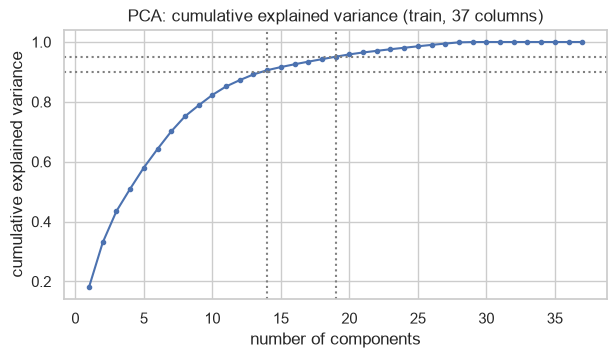

In [19]:
# ขั้น 8.1 — PCA (feature extraction): สร้างแกนใหม่ (PC) ที่เป็นผลรวมเชิงเส้นของ feature เดิม เรียงตาม variance ที่อธิบายได้
# ต่างจากขั้น 7: PCA "สร้าง" feature ใหม่ ไม่ได้ "เลือก" feature เดิม และไม่ได้ดู y เลย
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor

# ต้อง standardize ก่อน PCA ไม่อย่างนั้นตัวแปรสเกลใหญ่ (เช่น visibility) จะครอบงำทุก PC
pre_cy = make_preprocessor("cyclic").fit(X_train)
Xt_cy = pd.DataFrame(pre_cy.transform(X_train), columns=pre_cy.get_feature_names_out())
pca_full = PCA(random_state=config.RANDOM_STATE).fit(Xt_cy)
cum = np.cumsum(pca_full.explained_variance_ratio_)            # variance สะสม
n90, n95 = int(np.searchsorted(cum, 0.90) + 1), int(np.searchsorted(cum, 0.95) + 1)   # ต้องใช้กี่ PC ถึง 90% / 95%
print(f"จำนวนคอลัมน์ก่อน PCA: {Xt_cy.shape[1]}")
print("สัดส่วน variance ที่อธิบายได้ PC1–PC5:", pca_full.explained_variance_ratio_[:5].round(3).tolist())
print(f"ต้องใช้ {n90} components เพื่อให้ได้ ≥ 90% และ {n95} components เพื่อให้ได้ ≥ 95%")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(1, len(cum) + 1), cum, marker="o", ms=3)
for level, n in [(0.90, n90), (0.95, n95)]:
    ax.axhline(level, color="gray", ls=":")
    ax.axvline(n, color="gray", ls=":")
ax.set(title="PCA: cumulative explained variance (train, 37 columns)", xlabel="number of components", ylabel="cumulative explained variance")
savefig("08_pca_variance.png")
plt.show()

**ผลลัพธ์:**
- PC1–PC5 อธิบาย variance **18.1%, 14.9%, 10.4%, 7.5%, 7.1%**
- ต้องใช้ **14 PC** เพื่อ ≥90% และ **19 PC** เพื่อ ≥95% จาก 37 คอลัมน์ · การลดมิติต้องให้ CV ตัดสินผลต่อความแม่น ไม่เลือกจาก variance อย่างเดียว

### 8.2 ตีความ PC แรกๆ (loading)
**โค้ดทำอะไร:** ดู 5 คอลัมน์ที่มีน้ำหนัก (loading) มากที่สุดของ PC1–PC3 — เครื่องหมายบอกทิศทาง, ขนาดบอกว่ามีส่วนมากแค่ไหน

In [20]:
# ขั้น 8.2 — ตีความ PC1–PC3 จาก loading (น้ำหนักของ feature เดิมในแต่ละ PC): ขนาดบอกว่ามีส่วนมากแค่ไหน เครื่องหมายบอกทิศทาง
loadings = pd.DataFrame(pca_full.components_[:3].T, index=Xt_cy.columns, columns=["PC1", "PC2", "PC3"])
for pc in loadings:
    top5 = loadings[pc].reindex(loadings[pc].abs().sort_values(ascending=False).index)[:5].round(2)
    print(f"{pc}: {top5.to_dict()}")

PC1: {'humidity_pct': 0.51, 'dew_point_c': 0.36, 'is_raining': 0.34, 'visibility_10m': -0.32, 'rain_prev_3h': 0.27}
PC2: {'temp_c': 0.55, 'solar_radiation_mj': 0.45, 'dew_point_c': 0.43, 'hour_cos': -0.31, 'hour_sin': -0.22}
PC3: {'rainfall_mm': 0.46, 'is_raining': 0.41, 'rain_prev_3h': 0.41, 'hour_cos': -0.3, 'wind_speed_ms': 0.3}


**ผลลัพธ์:**
- **PC1**: humidity_pct +0.51, dew_point_c +0.36, is_raining +0.34, visibility_10m -0.32, rain_prev_3h +0.27
- **PC2**: temp_c +0.55, solar_radiation_mj +0.45, dew_point_c +0.43, hour_cos -0.31, hour_sin -0.22
- **PC3**: rainfall_mm +0.46, is_raining +0.41, rain_prev_3h +0.41, hour_cos -0.30, wind_speed_ms +0.30

(อนุมาน) คอลัมน์ที่มีน้ำหนักสัมบูรณ์สูงมีส่วนในแกนนั้นมากกว่า; loading เป็นความสัมพันธ์ ไม่ยืนยันเหตุและผล · เครื่องหมายแกน PCA กลับได้โดย variance ไม่เปลี่ยน

### 8.3 เทียบ CV: มี PCA vs ไม่มี PCA
**โค้ดทำอะไร:** ใส่ `PCA(n_components)` ในช่อง `select` ของ Pipeline (fit ใหม่ทุก fold) แล้วเทียบ MAE กับ Pipeline ที่ไม่มี PCA · ลองกับ Linear Regression และ kNN (tree-based ไม่ได้ประโยชน์จาก PCA เพราะ PC ผสมหลาย feature จนตัดแบ่งทีละ feature ได้ยากขึ้น)
- ใช้ `hour="cyclic"` ทั้งสองโมเดลเพื่อให้เริ่มจาก 37 คอลัมน์ชุดเดียวกับ 8.1

In [21]:
# ขั้น 8.3 — PCA ช่วยโมเดลไหม: ใส่ PCA ในช่อง select ของ Pipeline (fit ใหม่ทุก fold) แล้วเทียบ CV MAE กับไม่ใส่
# ลองกับ Linear และ kNN — tree-based ไม่ได้ประโยชน์เพราะ PC ผสมหลาย feature จนตัดแบ่งทีละ feature ยากขึ้น
N_PCA = [5, 10, 15, 20, 25]
pca_rows = []
for name, model, hour in [("Linear", LinearRegression(), "cyclic"), ("kNN (k=10)", KNeighborsRegressor(n_neighbors=10), "cyclic")]:
    no = cv_report(make_pipeline(model, hour=hour), name)
    gs = grid(make_pipeline(model, select=PCA(random_state=config.RANDOM_STATE), hour=hour), {"select__n_components": N_PCA})
    row = {"model": name, "ไม่มี PCA": no["MAE"]}
    row.update({f"PCA {n}": m for n, m in zip(N_PCA, -gs.cv_results_["mean_test_score"])})
    pca_rows.append(row)
pca_table = pd.DataFrame(pca_rows).set_index("model").round(1)
print("CV MAE (คัน/ชม.) — hour แบบ cyclic (37 คอลัมน์ก่อน PCA)")
print(pca_table)

CV MAE (คัน/ชม.) — hour แบบ cyclic (37 คอลัมน์ก่อน PCA)
            ไม่มี PCA  PCA 5  PCA 10  PCA 15  PCA 20  PCA 25
model                                                       
Linear          311.3  358.7   338.3   324.6   327.1   313.8
kNN (k=10)      191.9  199.3   190.6   184.1   206.0   193.6


**ผลลัพธ์:**
- **Linear (cyclic):** ไม่มี PCA 311.3 · PCA 5 = 358.7, PCA 25 = 313.8 · ใน grid นี้ PCA ไม่ลด MAE
- **kNN (k=10):** ไม่มี PCA 191.9 · ดีที่สุด **PCA 15 = 184.1**, ลด 7.8 คัน/ชม.

**ตัดสินใจ:** ไม่ใช้ PCA กับ Linear · คง PCA(15) เป็นตัวเลือกของ kNN ในขั้น 11 แล้วใช้ CV เลือกเหมือน grid เดิม

---
## ขั้น 9 — Baseline (เพดานล่างที่ทุกโมเดลต้องชนะ)

**โค้ดทำอะไร:** วัด 3 baseline ด้วย `cv_report` (GroupKFold ชุดเดียวกับโมเดลจริง)
| baseline | ทายอย่างไร | บอกอะไร |
|---|---|---|
| `DummyRegressor(mean)` | ค่าเฉลี่ยของ training fold ทุกชั่วโมง | ถ้าไม่รู้อะไรเลย จะคลาดเท่าไร |
| `DummyRegressor(median)` | มัธยฐานของ training fold (ค่าคงที่ที่ทำให้ MAE ต่ำสุด) | เหมือนข้างบนแต่เหมาะกับ MAE กว่า |
| **เวลาอย่างเดียว** (`HourDayTypeMean`) | ค่าเฉลี่ยของ training fold แยกตาม **ชั่วโมง × (วันทำงาน / วันหยุด)** — 48 กลุ่ม | ถ้าใช้แค่ "ปฏิทิน" ไม่ใช้อากาศเลย จะได้แค่ไหน → โมเดลจริงต้องชนะตัวนี้ชัดเจน จึงพิสูจน์ได้ว่าข้อมูลอากาศมีประโยชน์ |

`HourDayTypeMean` เขียนเป็น estimator ของ sklearn (`fit` / `predict`) → ค่าเฉลี่ยถูกเรียนจาก training fold เท่านั้นเหมือนโมเดลอื่น · "วันหยุด" = เสาร์–อาทิตย์ หรือวันหยุดนักขัตฤกษ์ (`01_eda` 4.5: สองแบบนี้มีรูปร่างรายชั่วโมงเหมือนกัน)

In [22]:
# ขั้น 9 — Baseline: วัดว่าการทายแบบง่ายที่สุดคลาดเท่าไร เพื่อเป็นเกณฑ์ขั้นต่ำที่โมเดลจริงต้องชนะ
# ใช้ cv_report (GroupKFold ชุดเดียวกับโมเดลจริง) → เทียบกันได้ตรงๆ
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.dummy import DummyRegressor


# เขียนเป็น estimator ของ sklearn (fit/predict) → ค่าเฉลี่ยถูกเรียนจาก training fold เท่านั้นเหมือนโมเดลอื่น
class HourDayTypeMean(BaseEstimator, RegressorMixin):
    """baseline จากเวลาอย่างเดียว: ทาย = ค่าเฉลี่ยยอดเช่าของ (ชั่วโมง, วันทำงาน/วันหยุด) ที่เรียนจากข้อมูล fit เท่านั้น"""

    def fit(self, X, y):
        key = self._key(X)
        self.table_ = pd.Series(np.asarray(y), index=key).groupby(level=[0, 1]).mean()   # 24 ชั่วโมง × 2 ประเภทวัน = 48 ค่า
        self.global_mean_ = float(np.mean(y))
        return self

    def predict(self, X):
        idx = pd.MultiIndex.from_arrays(self._key(X))
        return self.table_.reindex(idx).fillna(self.global_mean_).to_numpy()   # กลุ่มที่ไม่เคยเห็น → ใช้ค่าเฉลี่ยรวม

    @staticmethod
    def _key(X):
        # วันหยุด = เสาร์–อาทิตย์ หรือวันหยุดนักขัตฤกษ์ (รูปแบบรายชั่วโมงเหมือนกันใน 01_eda 4.5)
        off_day = ((X["is_weekend"] == 1) | (X["is_holiday"] == 1)).astype(int).to_numpy()
        return [X["hour"].to_numpy(), off_day]


baseline_rows = [
    cv_report(DummyRegressor(strategy="mean"), "Dummy (mean)"),       # ทายค่าเฉลี่ยทุกชั่วโมง
    cv_report(DummyRegressor(strategy="median"), "Dummy (median)"),   # ทายมัธยฐาน (ค่าคงที่ที่ทำให้ MAE ต่ำสุด)
    cv_report(HourDayTypeMean(), "เวลาอย่างเดียว (hour × วันทำงาน/วันหยุด)"),
]
baselines = pd.DataFrame(baseline_rows).set_index("model").round(3)
baselines[["MAE", "MAE_std", "MSE", "RMSE", "R2", "MAE_train"]].round({"MAE": 1, "MAE_std": 1, "MSE": 0, "RMSE": 1, "R2": 3, "MAE_train": 1})

,MAE,MAE_std,MSE,RMSE,R2,MAE_train
model,,,,,,
Dummy (mean),527.6,11.8,423684.0,650.7,-0.003,527.3
Dummy (median),512.6,14.1,453973.0,673.4,-0.074,512.2
เวลาอย่างเดียว (hour × วันทำงาน/วันหยุด),398.4,10.9,267639.0,517.2,0.365,394.0


**ผลลัพธ์:**
- Dummy mean: MAE **527.6**, RMSE 650.7, MSE 423,684, R² -0.003
- Dummy median: MAE **512.6**, RMSE 673.4, MSE 453,973, R² -0.074 · median ลด absolute error แต่ไม่ได้ลด squared error
- เวลาอย่างเดียว: MAE **398.4**, R² 0.365 · ลด MAE จาก Dummy median 22%

**ตัดสินใจ:** โมเดลที่มีอากาศต้องชนะ baseline เวลาอย่างเดียว 398.4 อย่างชัดเจนบน CV ชุดเดียวกัน

---
## ขั้น 10 — เทียบ 4 โมเดลด้วย GroupKFold

**โค้ดทำอะไร:** วัด 4 โมเดลจาก 4 ตระกูลด้วยค่า default (ยังไม่ tune) ผ่าน `cv_report` · ทุกตัวใช้ทุก feature (ตามขั้น 7) และเลือก `hour=` ตามตารางในขั้น 5.4
| # | โมเดล | ตระกูล | `hour=` |
|---|---|---|---|
| 1 | `LinearRegression` | เส้นตรง | `"onehot"` |
| 2 | `KNeighborsRegressor(n_neighbors=10)` | ระยะทาง | `"cyclic"` |
| 3 | `RandomForestRegressor(n_estimators=200)` | ต้นไม้หลายต้นแบบ bagging (เฉลี่ยต้นไม้อิสระ) | `"raw"` |
| 4 | `HistGradientBoostingRegressor` | ต้นไม้หลายต้นแบบ boosting (ต้นใหม่แก้ error ต้นก่อน) | `"raw"` |

`gap (CV − train)` = MAE บน validation ลบ MAE บน training fold → ยิ่งมาก = ยิ่ง overfit

In [23]:
# ขั้น 10 — เทียบ 4 โมเดลจาก 4 ตระกูลด้วยค่า default (ยังไม่ tune) ผ่าน GroupKFold ชุดเดียวกัน
# แต่ละตัวใช้ encoding ชั่วโมงที่เหมาะกับตัวเอง: เส้นตรง → onehot, ระยะทาง → cyclic, ต้นไม้ → raw
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

MODELS = {
    "Linear Regression": (LinearRegression(), "onehot"),                       # เส้นตรง: เร็ว อ่าน coefficient ได้
    "kNN": (KNeighborsRegressor(n_neighbors=10), "cyclic"),                   # ระยะทาง: ไม่สมมติรูปร่างความสัมพันธ์
    "Random Forest": (RandomForestRegressor(n_estimators=200, n_jobs=1, random_state=config.RANDOM_STATE), "raw"),   # bagging
    "HistGradientBoosting": (HistGradientBoostingRegressor(random_state=config.RANDOM_STATE), "raw"),               # boosting
}
compare = pd.DataFrame([cv_report(make_pipeline(m, hour=h), name) for name, (m, h) in MODELS.items()]).set_index("model")
# gap = MAE บน validation − MAE บน train: gap ใหญ่ = overfit (จำ train) · gap เล็กแต่ MAE สูง = underfit
compare["gap (CV − train)"] = compare["MAE"] - compare["MAE_train"]
compare[["MAE", "MAE_std", "MSE", "RMSE", "R2", "MAE_train", "gap (CV − train)", "fit_s"]].round(
    {"MAE": 1, "MAE_std": 1, "MSE": 0, "RMSE": 1, "R2": 3, "MAE_train": 1, "gap (CV − train)": 1, "fit_s": 2})

,MAE,MAE_std,MSE,RMSE,R2,MAE_train,gap (CV − train),fit_s
model,,,,,,,,
Linear Regression,262.5,3.7,117602.0,342.9,0.721,257.3,5.2,0.03
kNN,191.9,7.4,81643.0,285.5,0.806,151.9,40.1,0.02
Random Forest,119.1,4.5,38279.0,195.2,0.909,36.6,82.5,4.47
HistGradientBoosting,109.2,2.9,32321.0,179.6,0.923,66.8,42.4,0.58


**ผลลัพธ์:**
- **Linear Regression**: CV MAE 262.5 ± 3.7, MSE 117,602, RMSE 342.9, R² 0.721 · train MAE 257.3, gap 5.2
- **kNN**: CV MAE 191.9 ± 7.4, MSE 81,643, RMSE 285.5, R² 0.806 · train MAE 151.9, gap 40.1
- **Random Forest**: CV MAE 119.1 ± 4.5, MSE 38,279, RMSE 195.2, R² 0.909 · train MAE 36.6, gap 82.5
- **HistGradientBoosting**: CV MAE 109.2 ± 2.9, MSE 32,321, RMSE 179.6, R² 0.923 · train MAE 66.8, gap 42.4

ทุกตัวชนะ baseline เวลาอย่างเดียว 398.4 · ค่า default ที่ MAE ต่ำสุดคือ HistGradientBoosting · เลือกขั้นสุดท้ายหลัง tuning ด้วย CV; เวลา fit ใน output ขึ้นกับเครื่อง/โหลดของรอบนี้

**โค้ดทำอะไร:** วาดกราฟแท่ง MAE ± std ของ baseline (สีเทา) และ 4 โมเดล (สีน้ำเงิน)

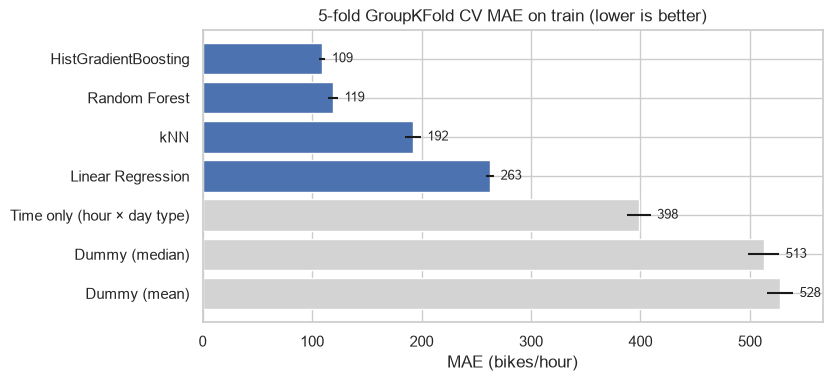

In [24]:
# ขั้น 10 (ต่อ) — กราฟ MAE ± std ของ baseline (เทา) เทียบกับ 4 โมเดล (น้ำเงิน) → เห็นว่าทุกโมเดลชนะ baseline แค่ไหน
plot_df = pd.concat([baselines[["MAE", "MAE_std"]], compare[["MAE", "MAE_std"]]]).sort_values("MAE", ascending=False)
plot_df = plot_df.rename(index={"เวลาอย่างเดียว (hour × วันทำงาน/วันหยุด)": "Time only (hour × day type)"})   # ฟอนต์กราฟไม่มีภาษาไทย
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(plot_df.index, plot_df["MAE"], xerr=plot_df["MAE_std"],
        color=["C0" if n in compare.index else "lightgray" for n in plot_df.index])   # เทา = baseline
for i, (v, sd) in enumerate(zip(plot_df["MAE"], plot_df["MAE_std"])):
    ax.text(v + sd + 6, i, f"{v:.0f}", va="center", fontsize=9)
ax.set(title="5-fold GroupKFold CV MAE on train (lower is better)", xlabel="MAE (bikes/hour)")
savefig("10_model_comparison.png")
plt.show()

**ผลลัพธ์:** baseline มี MAE 398–528 ห่างจากโมเดลที่ใช้อากาศ · error bar คือ std ระหว่าง folds ไม่ใช่การทดสอบความต่างทางสถิติ

---
## ขั้น 11 — Hyperparameter tuning

**โค้ดทำอะไร:** tune ทีละโมเดลด้วย `cv` + `groups=groups_train` + `scoring="neg_mean_absolute_error"` (test ยังปิดอยู่)
| โมเดล | วิธีค้น | สิ่งที่ลอง |
|---|---|---|
| Linear Regression | – (ไม่มีไฮเปอร์พารามิเตอร์) | ฝึกบน y ดิบ vs **`log1p(y)`** |
| kNN | `GridSearchCV` (28 ชุด) | `n_neighbors` 3–30, `weights` uniform/distance, มี/ไม่มี `PCA(15)` (ขั้น 8) · และแบบ `log1p(y)` |
| Random Forest | `RandomizedSearchCV` (สุ่ม 15 จาก 64 ชุด) | `n_estimators`, `min_samples_leaf`, `max_features`, `max_depth` |
| HistGradientBoosting | `RandomizedSearchCV` (สุ่ม 30 จาก 480 ชุด) | `learning_rate`, `max_iter`, `max_leaf_nodes`, `min_samples_leaf`, `l2_regularization` · และลอง `log1p(y)` กับพารามิเตอร์ที่ดีที่สุด |

**`log1p(y)` ทำงานอย่างไร:** `TransformedTargetRegressor` ฝึกโมเดลบน $\log(1 + y)$ แล้วแปลงค่าทำนายกลับด้วย $e^{\hat{z}} - 1$ ก่อนคิดคะแนน → **MAE ยังเป็นหน่วยคัน/ชม.** และการแปลงอยู่ใน Pipeline จึง fit ใหม่ทุก fold

⏱️ cell นี้ใช้เวลาหลายนาที (RF และ HGB ต้อง fit หลายร้อยครั้ง)

In [25]:
# ขั้น 11 — Hyperparameter tuning ทีละโมเดลด้วย CV บน train (GroupKFold + groups, เลือกด้วย MAE) · test ยังปิดอยู่
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import RandomizedSearchCV


def log_target(pipe):
    """ฝึกบน log1p(y) แล้วแปลงค่าทำนายกลับด้วย expm1 → MAE ยังวัดเป็นคัน/ชม."""
    # y เบ้ขวาและผลของอากาศเป็นแบบ "คูณ" → บนสเกล log กลายเป็น "บวก" ซึ่งโมเดลเชิงเส้นจับได้
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)


def rsearch(pipe, dist, n_iter):
    # RandomizedSearchCV: สุ่มลอง n_iter ชุดจาก grid ใหญ่ — ถูกกว่าลองทุกชุด (GridSearch) มากเมื่อพารามิเตอร์เยอะ
    rs = RandomizedSearchCV(pipe, dist, n_iter=n_iter, cv=cv, scoring="neg_mean_absolute_error",
                            n_jobs=-1, random_state=config.RANDOM_STATE)
    return rs.fit(X_train, y_train, groups=groups_train)


searches = {}
t0 = time.time()
# Linear: ไม่มีไฮเปอร์พารามิเตอร์ → ลองแค่ "แปลง y ด้วย log1p หรือไม่"
searches["Linear Regression"] = grid(make_pipeline(LinearRegression(), hour="onehot"), {"model__fit_intercept": [True]})
searches["Linear Regression + log1p(y)"] = grid(log_target(make_pipeline(LinearRegression(), hour="onehot")),
                                                 {"regressor__model__fit_intercept": [True]})
# kNN: จำนวนเพื่อนบ้าน, การถ่วงน้ำหนัก, PCA (ขั้น 8), log1p(y)
searches["kNN"] = grid(make_pipeline(KNeighborsRegressor(), hour="cyclic"), {
    "model__n_neighbors": [3, 5, 7, 10, 15, 20, 30],
    "model__weights": ["uniform", "distance"],       # distance = เพื่อนบ้านที่ใกล้กว่ามีน้ำหนักมากกว่า
    "select": ["passthrough", PCA(n_components=15, random_state=config.RANDOM_STATE)],
})
searches["kNN + log1p(y)"] = grid(log_target(make_pipeline(KNeighborsRegressor(), hour="cyclic")), {
    "regressor__model__n_neighbors": [5, 10, 15, 20, 30],
    "regressor__model__weights": ["uniform", "distance"],
})
# Random Forest — min_samples_leaf / max_depth คุมความลึกของต้นไม้ (ลด overfit) · max_features สุ่ม feature ต่อการแบ่ง
searches["Random Forest"] = rsearch(
    make_pipeline(RandomForestRegressor(n_jobs=1, random_state=config.RANDOM_STATE), hour="raw"), {
        "model__n_estimators": [200, 300],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": [0.33, 0.5, 0.75, 1.0],
        "model__max_depth": [None, 20],
    }, n_iter=15)
# HistGradientBoosting — learning_rate ต่ำ + max_iter มาก = เรียนช้าแต่ละเอียด · max_leaf_nodes = ขนาดต้นไม้ · l2 = regularization
searches["HistGradientBoosting"] = rsearch(
    make_pipeline(HistGradientBoostingRegressor(random_state=config.RANDOM_STATE), hour="raw"), {
        "model__learning_rate": [0.02, 0.03, 0.05, 0.1, 0.2],
        "model__max_iter": [200, 400, 800],
        "model__max_leaf_nodes": [15, 31, 63, 127],
        "model__min_samples_leaf": [5, 10, 20, 40],
        "model__l2_regularization": [0.0, 1.0],
    }, n_iter=30)
# tree + log1p(y): ใช้พารามิเตอร์ที่ดีที่สุดของ HGB แล้วเปลี่ยนแค่การแปลง y
from sklearn.base import clone
hgb_log = cv_report(log_target(clone(searches["HistGradientBoosting"].best_estimator_)), "HistGradientBoosting + log1p(y)")
print(f"เวลาทั้งหมด {time.time() - t0:.0f} วินาที")

# สรุปผล tuning: CV MAE ของพารามิเตอร์ที่ดีที่สุด เทียบกับค่า default จากขั้น 10
tuned = pd.DataFrame([{
    "model": name,
    "CV MAE": -s.best_score_,
    "MAE_std": s.cv_results_["std_test_score"][s.best_index_],
    "best params": {k.split("__")[-1]: (type(v).__name__ if hasattr(v, "fit") else v) for k, v in s.best_params_.items()
                    if not k.endswith("fit_intercept")},
} for name, s in searches.items()]).set_index("model")
tuned["ก่อน tune"] = [compare["MAE"].get(n.replace(" + log1p(y)", ""), np.nan) if "log1p" not in n else np.nan for n in tuned.index]
tuned.loc["HistGradientBoosting + log1p(y)"] = [hgb_log["MAE"], hgb_log["MAE_std"], "(พารามิเตอร์เดียวกับ HGB)", np.nan]
print(tuned.round(1).to_string())

เวลาทั้งหมด 219 วินาที
                                 CV MAE  MAE_std                                                                                                      best params  ก่อน tune
model                                                                                                                                                                       
Linear Regression                 262.5      3.7                                                                                                               {}      262.5
Linear Regression + log1p(y)      205.9     10.0                                                                                                               {}        NaN
kNN                               177.1      6.9                                                       {'n_neighbors': 5, 'weights': 'distance', 'select': 'PCA'}      191.9
kNN + log1p(y)                    186.2     11.7                                                                

**ผลลัพธ์:**
- **Linear Regression**: CV MAE **262.5 ± 3.7** · พารามิเตอร์ {}
- **Linear Regression + log1p(y)**: CV MAE **205.9 ± 10.0** · พารามิเตอร์ {}
- **kNN**: CV MAE **177.1 ± 6.9** · พารามิเตอร์ {'n_neighbors': 5, 'weights': 'distance', 'select': 'PCA'}
- **kNN + log1p(y)**: CV MAE **186.2 ± 11.7** · พารามิเตอร์ {'n_neighbors': 15, 'weights': 'distance'}
- **Random Forest**: CV MAE **117.8 ± 3.8** · พารามิเตอร์ {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.75, 'max_depth': None}
- **HistGradientBoosting**: CV MAE **104.6 ± 3.2** · พารามิเตอร์ {'min_samples_leaf': 5, 'max_leaf_nodes': 63, 'max_iter': 200, 'learning_rate': 0.05, 'l2_regularization': 0.0}
- **HistGradientBoosting + log1p(y)**: CV MAE **107.1 ± 7.8** · พารามิเตอร์ (พารามิเตอร์เดียวกับ HGB)

Linear + log1p ลด MAE จาก 262.5 เป็น 205.9 · เลือกจาก CV เท่านั้น ไม่ย้อนปรับตาม test · รอบนี้เพิ่ม rain_prev_3h ที่ผ่านเกณฑ์ train CV แต่คง search space เดิมไว้; FS แยกโมเดลอยู่ใน PR ถัดไป

---
## ขั้น 12 — เลือกโมเดล + ตาราง CLO4

**โค้ดทำอะไร:** เอาตัวที่ดีที่สุดของแต่ละตระกูลจากขั้น 11 (Linear ใช้แบบ log1p) มาวัดทรัพยากรที่ใช้
- **CV MAE ± std** จากขั้น 11 (เกณฑ์หลักในการเลือก — **ไม่ได้ดู test**)
- **fit ทั้ง train** = เวลาฝึกใหม่บน train ทั้ง 6,672 แถว 1 ครั้ง
- **latency / 1 แถว** = มัธยฐานของเวลาทำนาย 1 แถว 30 ครั้ง (แบบที่แอปจะใช้จริง)

⚠️ เวลา (fit, latency) เปลี่ยนเล็กน้อยทุกครั้งที่รันและขึ้นกับเครื่อง ใช้ดู "ลำดับขนาด" ไม่ใช่ค่าแน่นอน

In [26]:
# ขั้น 12 — เลือกโมเดลสุดท้าย: เทียบตัวที่ดีที่สุดของแต่ละตระกูลทั้งความแม่น (CV MAE, เกณฑ์หลัก) และทรัพยากร (ตาราง CLO4)
FINALISTS = {   # ตัวที่ดีที่สุดของแต่ละตระกูลจากขั้น 11 (best_estimator_ ถูก refit บน train ทั้งหมดแล้ว)
    "Linear Regression + log1p(y)": searches["Linear Regression + log1p(y)"],
    "kNN": searches["kNN"],
    "Random Forest": searches["Random Forest"],
    "HistGradientBoosting": searches["HistGradientBoosting"],
}
one_row = X_train.iloc[[0]]          # ทำนายทีละ 1 แถว แบบที่แอปใช้งานจริง
rows = []
for name, s in FINALISTS.items():
    est = s.best_estimator_
    t0 = time.perf_counter()
    clone(est).fit(X_train, y_train)          # clone = สำเนาที่ยังไม่ fit → วัดเวลาฝึกใหม่โดยไม่ทับโมเดลเดิม
    fit_s = time.perf_counter() - t0
    lat = []
    for _ in range(30):
        t0 = time.perf_counter()
        est.predict(one_row)
        lat.append(time.perf_counter() - t0)
    rows.append({
        "model": name,
        "CV MAE": -s.best_score_, "± std": s.cv_results_["std_test_score"][s.best_index_],
        "fit ทั้ง train (s)": fit_s, "latency / 1 แถว (ms)": 1000 * np.median(lat),   # มัธยฐาน 30 ครั้ง ลดผลของรอบที่สะดุด
    })
clo4 = pd.DataFrame(rows).set_index("model").sort_values("CV MAE")   # เรียงตาม CV MAE → แถวแรกคือตัวที่เลือก
clo4.round({"CV MAE": 1, "± std": 1, "fit ทั้ง train (s)": 2, "latency / 1 แถว (ms)": 1})

,CV MAE,± std,fit ทั้ง train (s),latency / 1 แถว (ms)
model,,,,
HistGradientBoosting,104.6,3.2,0.86,4.1
Random Forest,117.8,3.8,4.02,10.4
kNN,177.1,6.9,0.02,2.9
Linear Regression + log1p(y),205.9,10.0,0.02,3.3


**ผลลัพธ์และตัดสินใจ:**
- เลือก **HistGradientBoosting**, CV MAE **104.6 ± 3.2** ต่ำสุดใน finalists ของรอบนี้
- เวลา fit ของผู้ชนะ 0.86 วินาที, latency median 4.1 ms/แถว · ค่าทรัพยากรเป็นผลวัดบนเครื่องนี้; ดูครบทุกโมเดลใน output
- ผลนี้เป็นโมเดลของ **ขั้น rain history** ยังต้องทดลอง FS แยกโมเดลตามลำดับงาน · เกณฑ์เลือกยังเป็น CV MAE

**โค้ดทำอะไร:** ตั้ง `final_model` = Pipeline ที่เลือก (`best_estimator_` ของ search ที่ชนะ ซึ่งถูก **refit บน train ทั้งหมด** ด้วยพารามิเตอร์ที่ดีที่สุดแล้ว) เพื่อใช้ต่อในขั้น 13
- Pipeline นี้รวม preprocess (imputer, scaler, one-hot) ไว้ในตัว → input คือ `X` 17 คอลัมน์แบบเดียวกับ `X_train` (หลัง `add_features`)
- ไม่บันทึกเป็นไฟล์ — ขั้น 13 ใช้ `final_model` ในหน่วยความจำโดยตรง (รัน notebook นี้ใหม่ได้โมเดลเดิมทุกครั้งเพราะตั้ง `random_state` ไว้)

In [27]:
# ขั้น 12 (ต่อ) — ตั้ง final_model = Pipeline ที่ CV MAE ต่ำสุด (เลือกจาก CV เท่านั้น ยังไม่ได้ดู test)
best_name = clo4.index[0]
final_model = FINALISTS[best_name].best_estimator_      # รวม preprocess + model ไว้ในตัว → รับ X ดิบ 18 คอลัมน์ได้เลย
print(f"โมเดลที่เลือก: {best_name} | CV MAE = {clo4.loc[best_name, 'CV MAE']:.1f} คัน/ชม.")
print(getattr(final_model, "named_steps", {}).get("model", final_model))

โมเดลที่เลือก: HistGradientBoosting | CV MAE = 104.6 คัน/ชม.
HistGradientBoostingRegressor(learning_rate=0.05, max_iter=200,
                              max_leaf_nodes=63, min_samples_leaf=5,
                              random_state=42)


**ผลลัพธ์:** `final_model` = **HistGradientBoosting** พร้อม Pipeline preprocess, CV MAE **104.6** คัน/ชม. · ส่งไปประเมิน test ที่กรองตามกฎคงที่แล้วในขั้น 13

---
## ขั้น 13 — ประเมิน test ในขอบเขต, error analysis, ทำนายข้อมูลใหม่

### 13.1 ประเมินหลังเลือกโมเดลด้วย CV
**โค้ดทำอะไร:** ใช้ `final_model` (**HistGradientBoosting**, เลือกจาก CV เท่านั้น) ทำนาย X_test **1,656 แถว** ที่ผ่านกฎคงที่ใน 5.2 · test ใช้ประเมินหลังเลือกโมเดลของรอบนี้ และไม่ใช้ย้อนปรับ scope rules, feature, selector หรือพารามิเตอร์ · clip ค่าติดลบเป็น 0 แล้วคำนวณ MAE/MSE/RMSE/R²

**การอ่านคะแนน:** รอบนี้ใช้ขอบเขตเดียวกับ PR scope rules และเลือกฝนย้อนหลังจากการเทียบ train CV ใน 5.3.1 · test เป็นผลประเมินหลังตรึง feature/โมเดล ไม่ใช่เกณฑ์ตัดสินใจเก็บ feature · รอบเก่าที่รวมวันพายุมีขอบเขตต่างกัน จึงเทียบคะแนนโดยตรงไม่ได้; การประเมินความไวรวมวันพายุจะทำในขั้นรันผลสุดท้าย

In [28]:
# ขั้น 13.1 — ประเมิน test "ครั้งเดียว": ครั้งแรกที่แตะ test และห้ามกลับไปแก้โมเดลหลังเห็นผล
# Pipeline แปลง X_test ด้วยค่าที่เรียนจาก train (median, mean/std) → ไม่มีข้อมูล test รั่วเข้าโมเดล
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

raw_pred = final_model.predict(X_test)
pred_test = np.clip(raw_pred, 0, None)          # จำนวนคันติดลบไม่ได้
test_scores = {
    "MAE": mean_absolute_error(y_test, pred_test),      # metric หลัก: คลาดเฉลี่ยกี่คัน/ชม.
    "MSE": mean_squared_error(y_test, pred_test),       # หน่วยเป็นคัน² → รายงานตามโจทย์ แต่อธิบายด้วย RMSE
    "RMSE": root_mean_squared_error(y_test, pred_test),
    "R2": r2_score(y_test, pred_test),                  # สัดส่วน variance ที่อธิบายได้
}
# เทียบกับ CV: ถ้าใกล้กัน = โมเดลไม่ overfit และ CV ประเมินได้สมจริง
cv_best = clo4.loc[best_name]
print(f"ค่าทำนายติดลบที่ถูก clip เป็น 0: {(raw_pred < 0).sum()} จาก {len(raw_pred):,} แถว")
print(pd.DataFrame({
    "CV บน train (5-fold)": [cv_best["CV MAE"], np.nan, np.nan, np.nan],
    "test (ครั้งเดียว)": [test_scores["MAE"], test_scores["MSE"], test_scores["RMSE"], test_scores["R2"]],
}, index=["MAE", "MSE", "RMSE", "R2"]).round(3))

ค่าทำนายติดลบที่ถูก clip เป็น 0: 12 จาก 1,656 แถว
      CV บน train (5-fold)  test (ครั้งเดียว)
MAE                104.595             91.538
MSE                    NaN          22831.715
RMSE                   NaN            151.102
R2                     NaN              0.936


**ผลลัพธ์:**
- clip ค่าทำนายติดลบ **12 จาก 1,656 แถว**
- test **ในขอบเขต**: MAE **91.5** คัน/ชม., MSE **22,831.7** คัน², RMSE **151.1**, R² **0.936** · CV MAE 104.6 ± 3.2
- test มีชั่วโมงฤดูหนาว 33.3% เทียบกับ train 24.1% · (อนุมาน) สัดส่วนฤดูและระดับยอดต่างกันมีส่วนให้ MAE test ต่ำกว่า CV; ค่าเฉลี่ยสองตัวนี้อย่างเดียวไม่ยืนยันว่าไม่มี overfit
- RMSE/MAE = 1.65 → ยังมี error ก้อนใหญ่ · ใช้ error analysis เพื่อรายงานข้อจำกัด ไม่ย้อนกลับไปเลือกโมเดลด้วย test

### 13.2 Error analysis แยกกลุ่ม
**โค้ดทำอะไร:** สร้างตาราง `res` (ค่าจริง, ค่าทำนาย, error = ทำนาย − จริง) แล้วสรุปตามฤดู / ประเภทวัน / ฝน
- `MAE / mean_y (%)` = ความคลาดเทียบกับระดับยอดปกติของกลุ่มนั้น (เทียบข้ามกลุ่มที่สเกลต่างกันได้)
- `bias` = ค่าเฉลี่ยของ error → บวก = ทายสูงเกินโดยเฉลี่ย

In [29]:
# ขั้น 13.2 — Error analysis แยกกลุ่ม: โมเดลพลาดตรงไหน (ฤดู / ประเภทวัน / ฝน)
res = test[["date", "hour", "seasons", "temp_c", "humidity_pct", "rainfall_mm", "is_weekend", "is_holiday"]].copy()
res["y"] = y_test.to_numpy()
res["pred"] = pred_test
res["error"] = res["pred"] - res["y"]          # บวก = ทายสูงเกิน
res["abs_error"] = res["error"].abs()
res["day_type"] = np.where((res["is_weekend"] == 1) | (res["is_holiday"] == 1), "วันหยุด", "วันทำงาน")


def group_err(col):
    # MAE / mean_y = ความคลาดเทียบกับระดับยอดของกลุ่ม → เทียบข้ามกลุ่มที่สเกลต่างกันได้ · bias = ทายสูง/ต่ำเกินโดยเฉลี่ย
    g = res.groupby(col).agg(n=("y", "size"), mean_y=("y", "mean"), MAE=("abs_error", "mean"), bias=("error", "mean"))
    g["MAE / mean_y (%)"] = 100 * g["MAE"] / g["mean_y"]
    return g.round(1)


print("แยกฤดู:")
print(group_err("seasons").sort_values("mean_y"))
print("\nแยกประเภทวัน:")
print(group_err("day_type"))
print("\nแยกฝน:")
print(group_err(np.where(res["rainfall_mm"] > 0, "ฝนตก", "ไม่มีฝน")))

แยกฤดู:
           n  mean_y    MAE  bias  MAE / mean_y (%)
seasons                                            
Winter   552   211.7   52.3   3.9              24.7
Spring   336   596.0   89.3  14.3              15.0
Autumn   408   799.8  124.6  39.5              15.6
Summer   360  1041.7  116.3   9.9              11.2

แยกประเภทวัน:
             n  mean_y   MAE  bias  MAE / mean_y (%)
day_type                                            
วันทำงาน  1104   681.7  97.9  11.2              14.4
วันหยุด    552   481.6  78.8  25.8              16.4

แยกฝน:
            n  mean_y    MAE  bias  MAE / mean_y (%)
ฝนตก       89   171.9  147.0  73.7              85.5
ไม่มีฝน  1567   640.2   88.4  12.8              13.8


**ผลลัพธ์:**
- ฤดู: Winter MAE **52.3** (24.7% ของยอดเฉลี่ย), Summer **116.3** (11.2%) · Autumn MAE **124.6** สูงสุดในรอบนี้; การเทียบเป็นคันและเป็นสัดส่วนให้ข้อสังเกตต่างกัน
- ประเภทวัน: วันทำงาน MAE 97.9, วันหยุด 78.8 · bias วันหยุด +25.8 (ทายสูงเกินโดยเฉลี่ย)
- ฝน: **89 แถว**, MAE **147.0**, ยอดเฉลี่ย 171.9 → **85.5%**; ไม่มีฝน 13.8% · ฝนยังเป็นจุดอ่อนของรอบนี้
- bias รวม +16.1 คัน/ชม. · รายงานกลุ่มหลังตรึงโมเดล; ไม่ใช้ผลเหล่านี้คัดแถว test เพิ่ม

### 13.3 กราฟค่าจริง vs ค่าทำนาย, residual, MAE รายชั่วโมง
**โค้ดทำอะไร:** (ซ้าย) scatter ค่าจริง vs ค่าทำนาย — จุดบนเส้นทแยง = ทายถูก · (กลาง) residual vs ค่าทำนาย — ควรกระจายรอบ 0 เท่าๆ กัน · (ขวา) MAE รายชั่วโมง (แท่ง) คู่กับยอดจริงเฉลี่ย (เส้น)

MAE สูงสุด 3 ชั่วโมง: {8: 181.0, 18: 171.0, 19: 138.0}
MAE ต่ำสุด 3 ชั่วโมง: {4: 24.0, 3: 28.0, 5: 28.0}


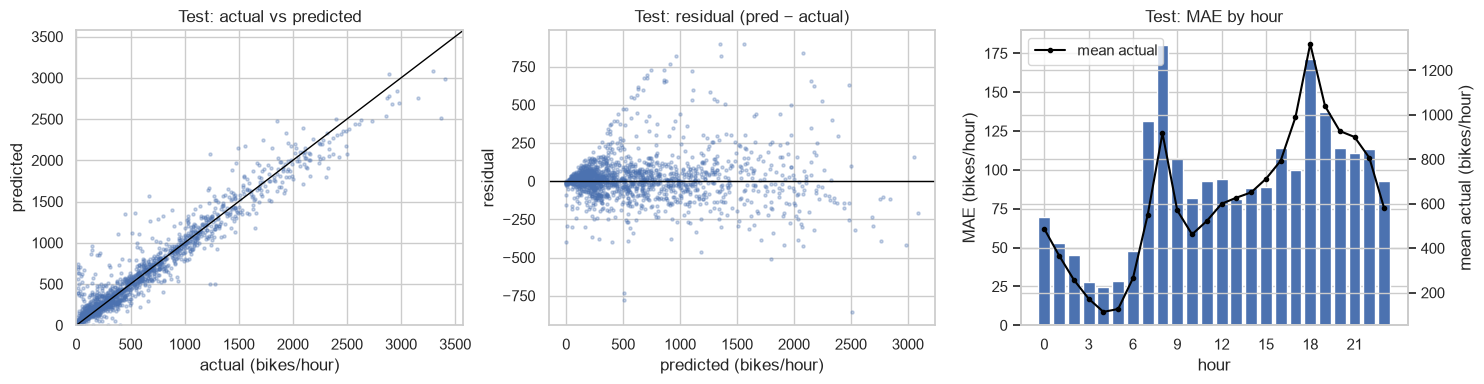

In [30]:
# ขั้น 13.3 — กราฟวินิจฉัย: (ซ้าย) ค่าจริง vs ค่าทำนาย (กลาง) residual (ขวา) MAE รายชั่วโมง
by_hour = res.groupby("hour")[["abs_error", "y"]].mean()
print("MAE สูงสุด 3 ชั่วโมง:", by_hour["abs_error"].nlargest(3).round(0).to_dict())
print("MAE ต่ำสุด 3 ชั่วโมง:", by_hour["abs_error"].nsmallest(3).round(0).to_dict())
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
lim = max(res["y"].max(), res["pred"].max()) * 1.05
ax[0].scatter(res["y"], res["pred"], s=5, alpha=0.3)
ax[0].plot([0, lim], [0, lim], color="black", lw=1)          # เส้นทแยง = ทายถูกพอดี
ax[0].set(title="Test: actual vs predicted", xlabel="actual (bikes/hour)", ylabel="predicted", xlim=(0, lim), ylim=(0, lim))
ax[1].scatter(res["pred"], res["error"], s=5, alpha=0.3)       # ถ้าเป็นรูปกรวย = error โตตามระดับยอด
ax[1].axhline(0, color="black", lw=1)
ax[1].set(title="Test: residual (pred − actual)", xlabel="predicted (bikes/hour)", ylabel="residual")
ax[2].bar(by_hour.index, by_hour["abs_error"])
ax2 = ax[2].twinx()                                             # แกน y ที่สองสำหรับยอดจริงเฉลี่ย
ax2.plot(by_hour.index, by_hour["y"], color="black", marker="o", ms=3, label="mean actual")
ax[2].set(title="Test: MAE by hour", xlabel="hour", ylabel="MAE (bikes/hour)", xticks=range(0, 24, 3))
ax2.set_ylabel("mean actual (bikes/hour)")
ax2.legend(loc="upper left")
plt.tight_layout()
savefig("13_test_errors.png")
plt.show()

**ผลลัพธ์ (เห็นอะไร):**
- scatter กระจายกว้างขึ้นเมื่อยอดสูง และมี residual ทั้งบวก/ลบ · (อนุมาน) ความคลาดเป็นคันขึ้นกับระดับยอด; ดูประกอบผลแยกฤดูใน 13.2
- MAE สูงสุด 3 ชั่วโมง: 08:00 (181), 18:00 (171), 19:00 (138) · ต่ำสุด: 04:00 (24), 03:00 (28), 05:00 (28)
- bias รวมเป็นบวก +16.1 แต่กราฟหรือ MAE รายกลุ่มอย่างเดียวไม่ได้ยืนยันสาเหตุของการทายพลาด

### 13.4 10 ชั่วโมงที่ทายพลาดมากที่สุด
**โค้ดทำอะไร:** เรียง `res` ตาม |error| แล้วดู 10 แถวบนสุดพร้อมสภาพอากาศและประเภทวัน

In [31]:
# ขั้น 13.4 — 10 ชั่วโมงที่ทายพลาดมากที่สุด พร้อมสภาพอากาศและประเภทวัน → หาสาเหตุที่ feature ไม่ครอบคลุม
worst = res.sort_values("abs_error", ascending=False).head(10)
worst.assign(date=worst["date"].dt.strftime("%Y-%m-%d (%a)"))[
    ["date", "hour", "seasons", "temp_c", "humidity_pct", "rainfall_mm", "day_type", "y", "pred", "error"]].round(0)

,date,hour,seasons,temp_c,humidity_pct,rainfall_mm,day_type,y,pred,error
1039,2018-07-09 (Mon),7,Summer,21.0,66.0,0.0,วันทำงาน,451,1350.0,899.0
1040,2018-07-09 (Mon),8,Summer,21.0,73.0,0.0,วันทำงาน,670,1565.0,895.0
1026,2018-06-22 (Fri),18,Summer,29.0,27.0,0.0,วันทำงาน,3365,2509.0,-856.0
1314,2018-09-24 (Mon),18,Autumn,20.0,35.0,0.0,วันหยุด,1237,2079.0,842.0
1413,2018-10-26 (Fri),21,Autumn,11.0,70.0,0.0,วันทำงาน,542,1363.0,821.0
1472,2018-11-08 (Thu),8,Autumn,11.0,89.0,0.0,วันทำงาน,148,967.0,819.0
752,2018-04-04 (Wed),8,Spring,10.0,86.0,0.0,วันทำงาน,1284,506.0,-778.0
1401,2018-10-26 (Fri),9,Autumn,12.0,86.0,0.0,วันทำงาน,144,912.0,768.0
776,2018-04-06 (Fri),8,Spring,6.0,90.0,0.0,วันทำงาน,1235,505.0,-730.0
835,2018-05-02 (Wed),19,Spring,13.0,93.0,0.0,วันทำงาน,131,860.0,729.0


**ผลลัพธ์:**
- 10 ชั่วโมงที่พลาดสูงสุดกระจายตามวันที่: 2018-07-09 (2 แถว), 2018-10-26 (2 แถว), 2018-06-22 (1 แถว), 2018-09-24 (1 แถว), 2018-11-08 (1 แถว), 2018-04-04 (1 แถว), 2018-04-06 (1 แถว), 2018-05-02 (1 แถว)
- แถวที่คลาดมากสุดคือ **2018-07-09 07:00**: จริง 451, ทาย 1350, error +899 คัน/ชม. · ดูอากาศ/ประเภทวันของทุกแถวใน output
- **23 ส.ค. ไม่อยู่ในตาราง** เพราะถูกกรองด้วย scope rule ภายนอกก่อนประเมิน ไม่ใช่เพราะโมเดลเรียนจนทายวัน Soulik ดีขึ้น · วันหยุดและวันฝนที่ยังอยู่ในขอบเขตยังแสดงความคลาดได้

**ตัดสินใจ:** เก็บ error ของทุกแถวใน test ที่อยู่ในขอบเขตไว้รายงาน; ไม่ลบ worst rows หรือปรับกฎตามตารางนี้ · ปัจจัยภายนอกที่ dataset ไม่มีเป็นข้อจำกัด ไม่ใช้ตารางยืนยันสาเหตุเอง

### 13.5 ทำนายข้อมูลใหม่ (สมมติ)
**โค้ดทำอะไร:** สร้าง 4 สถานการณ์สมมติในรูปแบบเดียวกับข้อมูลดิบ แล้วผ่าน `add_features()` (ฟังก์ชันเดียวกับขั้น 5.3) ก่อนส่งให้ `final_model`
- `dew_point_c` คำนวณจากอุณหภูมิ + ความชื้นด้วยสูตร Magnus ย้อนกลับ (`01_eda` 4.10) เพื่อให้ข้อมูลสมมติสอดคล้องกันทางกายภาพ
- เปรียบเทียบทีละปัจจัย: แถว 1 vs 2 = ผลของฝน · แถว 1 vs 3 = วันทำงาน vs เสาร์ · แถว 4 = เช้าฤดูหนาว

ทุกสถานการณ์กำหนด rain_prev_3h = 0 มม. เป็นสมมติฐานร่วม ไม่คำนวณประวัติจากแถว counterfactual ที่มีวัน/ชั่วโมงซ้ำกัน

In [32]:
# ขั้น 13.5 — ทำนายข้อมูลใหม่ (สมมติ): ใส่ข้อมูลรูปแบบเดียวกับข้อมูลดิบ → add_features() → final_model
# เปลี่ยนปัจจัยทีละตัวเพื่อดูว่าทิศทางของผลสมเหตุสมผลไหม: แถว 1 vs 2 = ฝน · แถว 1 vs 3 = วันทำงาน vs เสาร์
def dew_point(t, rh):
    """ย้อนสูตร Magnus (01_eda 4.10): อุณหภูมิ + ความชื้น → dew point (ให้ข้อมูลสมมติสอดคล้องกันทางกายภาพ)"""
    g = np.log(rh / 100) + 17.625 * t / (243.04 + t)
    return 243.04 * g / (17.625 - g)


scenarios = pd.DataFrame([
    # date, hour, temp, humidity, wind, visibility, solar, rain, snow, season, holiday
    ("2018-06-13", 18, 24.0, 60, 1.5, 2000, 0.5, 0.0, 0.0, "Summer", "No Holiday"),   # พุธ เย็น อากาศดี
    ("2018-06-13", 18, 20.0, 95, 1.5, 300, 0.1, 3.0, 0.0, "Summer", "No Holiday"),    # พุธ เย็น ฝนตก
    ("2018-06-16", 18, 24.0, 60, 1.5, 2000, 0.5, 0.0, 0.0, "Summer", "No Holiday"),   # เสาร์ เย็น อากาศดี
    ("2018-01-17", 8, -3.0, 40, 1.5, 2000, 0.1, 0.0, 0.0, "Winter", "No Holiday"),    # พุธ เช้า หนาว
], columns=["date", "hour", "temp_c", "humidity_pct", "wind_speed_ms", "visibility_10m",
            "solar_radiation_mj", "rainfall_mm", "snowfall_cm", "seasons", "holiday"])
scenarios["date"] = pd.to_datetime(scenarios["date"])
scenarios["dew_point_c"] = dew_point(scenarios["temp_c"], scenarios["humidity_pct"]).round(1)
scenarios["functioning_day"] = "Yes"
# แต่ละแถวเป็นสถานการณ์อิสระ ไม่ใช่ประวัติของกันและกัน: สมมติฝนรวม 3 ชั่วโมงก่อนหน้าเป็น 0 มม. ทุกแถว
scenarios["rain_prev_3h"] = 0.0
# ใช้ add_features() ฟังก์ชันเดียวกับตอนฝึก → feature ของข้อมูลใหม่ถูกสร้างแบบเดียวกันทุกประการ
X_new = add_features(scenarios)[FEATURES]
scenarios["ทำนาย (คัน/ชม.)"] = np.clip(final_model.predict(X_new), 0, None).round(0)
scenarios.assign(date=scenarios["date"].dt.strftime("%Y-%m-%d (%a)"))[
    ["date", "hour", "temp_c", "humidity_pct", "dew_point_c", "rainfall_mm", "seasons", "ทำนาย (คัน/ชม.)"]]

,date,hour,temp_c,humidity_pct,dew_point_c,rainfall_mm,seasons,ทำนาย (คัน/ชม.)
0,2018-06-13 (Wed),18,24.0,60,15.8,0.0,Summer,3064.0
1,2018-06-13 (Wed),18,20.0,95,19.2,3.0,Summer,755.0
2,2018-06-16 (Sat),18,24.0,60,15.8,0.0,Summer,2263.0
3,2018-01-17 (Wed),8,-3.0,40,-14.7,0.0,Winter,680.0


**ผลลัพธ์ของสถานการณ์สมมติ:**
- พุธ 18:00 ฤดูร้อน 24 °C ไม่มีฝน: **3,064** คัน/ชม. · สถานการณ์ฝน 3 มม. (ปรับอากาศให้สอดคล้องด้วย): **755**, ต่ำกว่า 75% ตามโมเดล
- เสาร์ 18:00 อากาศเหมือนแถวแรก: **2,263** · พุธ 08:00 ฤดูหนาว −3 °C: **680** คัน/ชม.
- ทุกแถวสมมติฝน 3 ชั่วโมงก่อนหน้า **0 มม.** ตาม input ที่กำหนด · ทิศทางสอดคล้องกับรูปแบบเวลา/ฤดู/ฝนใน EDA แต่เป็นการตรวจความสมเหตุสมผลของโมเดล ไม่ใช่การทดลองเชิงสาเหตุ · ชั่วโมงฝนตกยังมีความคลาดสูงใน 13.2

---
## สรุปผลของรอบ rain history
- โมเดลที่ชนะ CV: **HistGradientBoosting**, MAE **104.6 ± 3.2** คัน/ชม. · Pipeline รวม preprocess และไม่มีการบันทึกไฟล์โมเดล
- test ในขอบเขต **1,656 ชั่วโมง / 69 วัน**: MAE **91.5**, MSE 22,831.7, RMSE 151.1, R² **0.936** · ขอบเขตตรงกับ PR scope rules; ตัดสินใจเก็บ rain_prev_3h จาก train CV ไม่ใช้ test
- CV MAE ต่ำกว่า baseline เวลาอย่างเดียว (398.4) 74% · จุดอ่อนยังเป็นชั่วโมงฝนตกและบริบทภายนอกที่ไม่มีใน feature
- ลำดับงานถัดไป: ทดลอง FS แยกโมเดลด้วย train CV จากนั้นประเมินความไวรวมวันพายุด้วยโมเดลที่ตรึงแล้ว และ sync report/slides ตามผลสุดท้าย